# EDA de producción petrolera: todo el proceso paso a paso
**GRUPO 5 · MIACD02P01 · Notebook autónomo**

**Pregunta principal:** ¿Qué mejoras y oportunidades de mejora pueden identificarse a partir de las variaciones de producción, al comparar períodos equivalentes y considerar la cobertura y calidad de los datos?

Este archivo contiene las fuentes originales incorporadas, el código de lectura y limpieza, los cálculos, la construcción de todas las gráficas, las interpretaciones, cinco preguntas adicionales y las decisiones. No importa código del proyecto ni lee resultados o imágenes elaborados previamente.

**Cómo utilizarlo:** guarda este `.ipynb` en una carpeta de tu elección, ábrelo con Jupyter o VS Code, selecciona Python y ejecuta **Reiniciar kernel y ejecutar todo**, de arriba abajo. Para leer las explicaciones y salidas ya guardadas no necesitas volver a ejecutar.

**Dependencias de ejecución:** Python 3.12; pandas 3.0.1, numpy 2.3.5, openpyxl 3.1.5, matplotlib 3.11.2 e ipykernel 7.4.0. Si tu entorno no las tiene, puedes instalarlas en su terminal con `python -m pip install pandas==3.0.1 numpy==2.3.5 openpyxl==3.1.5 matplotlib==3.11.2 ipykernel==7.4.0`. El notebook no instala programas automáticamente.

Al ejecutar se crea `salidas_EDA_notebook/` con copias verificadas de las fuentes, tablas y gráficos. Esa carpeta es una **salida generada**; no necesitas descargarla ni preparar otros archivos para comenzar.

## Mapa de lectura
| Orden de ejecución | Qué aprenderás | Relación con la rúbrica |
|---|---|---|
| 0–1 | Herramientas, contexto y pregunta | EDA 1 |
| 2.1–2.4 | Abrir los tres archivos y describirlos | EDA 2; T1–T2 |
| 2.5–2.12 | Limpiar, unir, crear variables y auditar | Preparación para el EDA; T2–T5 |
| 3 | Estadísticas y distribución | EDA 3; T6 |
| 4 | Series, cohortes, correlación e incertidumbre | EDA 4; T6, T8 |
| 5 | Interpretar la calidad encontrada | EDA 5; T3–T4 |
| 6 | Segmentar, comparar y comprobar sensibilidad | EDA 6; T7 |
| 7 | Cinco preguntas y decisiones | EDA 7 |
| 8 | Validaciones, exportación y reproducibilidad | T8 |

La limpieza se ejecuta antes de calcular estadísticas. El paso EDA 5 vuelve sobre sus resultados para interpretarlos; no oculta una limpieza ejecutada en otro archivo. T1–T8 es una correspondencia propuesta, porque la rúbrica recibida no incluye sus enunciados oficiales.

## 0. Preparar herramientas y parámetros
Importamos bibliotecas generales. `pd` es pandas, para tablas; `np` es NumPy, para cálculos; `plt` es Matplotlib, para construir las gráficas aquí mismo. `Path` maneja rutas y `hashlib` verifica las fuentes. La semilla 2026 controla el remuestreo, no genera producción ficticia.

In [1]:
from pathlib import Path
from importlib.metadata import version
import base64
import hashlib
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import display, Markdown
%matplotlib inline

SEED = 2026
KEY = ['anio', 'mes', 'activo']
SMALL_N = 12  # Precaución descriptiva: menos de un ciclo anual.
SALIDAS = Path.cwd() / 'salidas_EDA_notebook'
FUENTES = SALIDAS / 'fuentes'
FIGURAS = SALIDAS / 'figuras'
for carpeta in [FUENTES, FIGURAS]:
    carpeta.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 25)
pd.set_option('display.max_rows', 20)
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.titleweight': 'bold',
})
AZUL, VERDE, CORAL, AMBAR = '#2079B0', '#098F75', '#D54163', '#DBA229'
print('Python:', sys.version.split()[0], '| Semilla:', SEED)
display(pd.DataFrame({
    'biblioteca': ['pandas', 'numpy', 'openpyxl', 'matplotlib', 'ipykernel'],
    'version': [version(x) for x in ['pandas', 'numpy', 'openpyxl', 'matplotlib', 'ipykernel']],
}))

Python: 3.12.14 | Semilla: 2026


,biblioteca,version
0,pandas,3.0.1
1,numpy,2.3.5
2,openpyxl,3.1.5
3,matplotlib,3.11.2
4,ipykernel,7.4.0


## 1. Contexto, pregunta y usuario · EDA 1
**Usuario:** analista de planificación y supervisión de producción. Necesita distinguir variaciones productivas, cambios de cobertura y problemas de medición para priorizar revisiones.

**Unidad de la tabla principal:** un activo en un mes. Las conclusiones describen los archivos aportados, no toda la producción nacional. Mayor volumen por día calendario no demuestra mayor eficiencia: faltan costos, pozos, paradas y días operativos.

In [2]:
objetivos = pd.DataFrame([
    {'pregunta': '¿Cómo evoluciona la producción?', 'unidad': 'activo-mes', 'salida': 'volumen, tasa diaria y n válido'},
    {'pregunta': '¿Qué activos conviene revisar?', 'unidad': 'activo y período equivalente', 'salida': 'cambio absoluto y porcentual'},
    {'pregunta': '¿El precio acompaña esos cambios?', 'unidad': 'mes de una cohorte fija', 'salida': 'correlación e incertidumbre descriptivas'},
])
display(objetivos)

,pregunta,unidad,salida
0,¿Cómo evoluciona la producción?,activo-mes,"volumen, tasa diaria y n válido"
1,¿Qué activos conviene revisar?,activo y período equivalente,cambio absoluto y porcentual
2,¿El precio acompaña esos cambios?,mes de una cohorte fija,correlación e incertidumbre descriptivas


## 2. Origen, estructura y preparación · EDA 2
### 2.1. Los tres archivos originales incorporados · T1
Se conserva una copia exacta de **un XLSX y dos CSV** aportados por el usuario. La celda siguiente es un contenedor de datos en Base64: convierte bytes en texto para transportarlos dentro del `.ipynb`. **No contiene una limpieza ni un análisis ocultos.** Puede aparecer plegada porque su contenido es largo; se puede expandir.

Las huellas SHA-256 certifican identidad con las copias entregadas; no certifican que estas sean idénticas a una descarga oficial. El nombre «acumulada» del XLSX se interpreta como historia de volúmenes mensuales; no se aplica una diferencia como si cada fila fuera un acumulado anual. Las unidades adoptadas son barriles/mes para crudo y miles de pies cúbicos/mes para gas, según la documentación del proyecto; el XLSX no explicita estas unidades. Precio: USD/barril de referencia agregado, no precio por activo. El catálogo no tiene metadatos de procedencia adicionales.

In [3]:
# Copias exactas de los datos; esta celda solo declara el contenedor.
DATOS_INCORPORADOS = {'produccion_original.xlsx': {'archivo': 'produccion_original.xlsx',
                              'nombre_entregado': 'eppec_prd_petroleo_acumulada_2026 (2).xlsx',
                              'bytes': 41438,
                              'sha256': 'ecfdc55ff37513772211970068df37c961ff472edf2917e55459f17db8a00e7c',
                              'origen': 'Copia aportada por el usuario; conservada sin modificaciones.',
                              'base64': '...'},
 'precios_original.csv': {'archivo': 'precios_original.csv',
                          'nombre_entregado': 'precio-petrleo-crudo-ecu (1).csv',
                          'bytes': 1937,
                          'sha256': '4c9555a412907cf57e5d91af22928a78613fe89f6466429131e2b15aff3cec56',
                          'origen': 'Copia aportada por el usuario; conservada sin modificaciones.',
                          'base64': '77u/IlBlcsOtb2RvIiwiUHJlY2lvIFBldHLDs2xlbyBDcnVkbyBFY3VhdG9yaWFubyBlbiBVU0QgcG9yIEJhcnJpbCIKIjIwMjEtMDEtMDEgMDA6MDA6MDAiLDQ4LjYKIjIwMjEtMDItMDEgMDA6MDA6MDAiLDU1LjYxCiIyMDIxLTAzLTAxIDAwOjAwOjAwIiw1OC43MgoiMjAyMS0wNC0wMSAwMDowMDowMCIsNTcuMjQKIjIwMjEtMDUtMDEgMDA6MDA6MDAiLDYxLjUyCiIyMDIxLTA2LTAxIDAwOjAwOjAwIiw2Ny4yOQoiMjAyMS0wNy0wMSAwMDowMDowMCIsNjYuODQKIjIwMjEtMDgtMDEgMDA6MDA6MDAiLDYxLjE0CiIyMDIxLTA5LTAxIDAwOjAwOjAwIiw2NC43NAoiMjAyMS0xMC0wMSAwMDowMDowMCIsNzUuMgoiMjAyMS0xMS0wMSAwMDowMDowMCIsNjguNDkKIjIwMjEtMTItMDEgMDA6MDA6MDAiLDYwLjI4CiIyMDIyLTAxLTAxIDAwOjAwOjAwIiw3Ny42MgoiMjAyMi0wMi0wMSAwMDowMDowMCIsODQuNjYKIjIwMjItMDMtMDEgMDA6MDA6MDAiLDEwMC4zOAoiMjAyMi0wNC0wMSAwMDowMDowMCIsOTQuNwoiMjAyMi0wNS0wMSAwMDowMDowMCIsMTAxLjMxCiIyMDIyLTA2LTAxIDAwOjAwOjAwIiwxMDQuNAoiMjAyMi0wNy0wMSAwMDowMDowMCIsODcuNDYKIjIwMjItMDgtMDEgMDA6MDA6MDAiLDgzLjI4CiIyMDIyLTA5LTAxIDAwOjAwOjAwIiw3Ny42CiIyMDIyLTEwLTAxIDAwOjAwOjAwIiw4MC41MQoiMjAyMi0xMS0wMSAwMDowMDowMCIsNzUuMzYKIjIwMjItMTItMDEgMDA6MDA6MDAiLDY5LjIKIjIwMjMtMDEtMDEgMDA6MDA6MDAiLDY1LjExCiIyMDIzLTAyLTAxIDAwOjAwOjAwIiw2NC4yCiIyMDIzLTAzLTAxIDAwOjAwOjAwIiw2MC43NgoiMjAyMy0wNC0wMSAwMDowMDowMCIsNjguNzIKIjIwMjMtMDUtMDEgMDA6MDA6MDAiLDYxLjM3CiIyMDIzLTA2LTAxIDAwOjAwOjAwIiw1OC4wOAoiMjAyMy0wNy0wMSAwMDowMDowMCIsNjUuNTgKIjIwMjMtMDgtMDEgMDA6MDA6MDAiLDc0LjY1CiIyMDIzLTA5LTAxIDAwOjAwOjAwIiw4Mi43MwoiMjAyMy0xMC0wMSAwMDowMDowMCIsNzguMjkKIjIwMjMtMTEtMDEgMDA6MDA6MDAiLDcxLjQKIjIwMjMtMTItMDEgMDA6MDA6MDAiLDY0LjI1CiIyMDI0LTAxLTAxIDAwOjAwOjAwIiw2NS4zNAoiMjAyNC0wMi0wMSAwMDowMDowMCIsNjkuOTcKIjIwMjQtMDMtMDEgMDA6MDA6MDAiLDczLjU3CiIyMDI0LTA0LTAxIDAwOjAwOjAwIiw3Ny42MgoiMjAyNC0wNS0wMSAwMDowMDowMCIsNzEuODUKIjIwMjQtMDYtMDEgMDA6MDA6MDAiLDcyLjE0CiIyMDI0LTA3LTAxIDAwOjAwOjAwIiw3NC41MQoiMjAyNC0wOC0wMSAwMDowMDowMCIsNjguMTMKIjIwMjQtMDktMDEgMDA6MDA6MDAiLDYyLjMzCiIyMDI0LTEwLTAxIDAwOjAwOjAwIiw2NS4zMwoiMjAyNC0xMS0wMSAwMDowMDowMCIsNjAuODMKIjIwMjQtMTItMDEgMDA6MDA6MDAiLDYyLjEzCiIyMDI1LTAxLTAxIDAwOjAwOjAwIiw2Ny4zCiIyMDI1LTAyLTAxIDAwOjAwOjAwIiw2NC44MgoiMjAyNS0wMy0wMSAwMDowMDowMCIsNjEuMzEKIjIwMjUtMDQtMDEgMDA6MDA6MDAiLDU2LjMzCiIyMDI1LTA1LTAxIDAwOjAwOjAwIiw1NS4wNgoiMjAyNS0wNi0wMSAwMDowMDowMCIsNjAuNTIKIjIwMjUtMDctMDEgMDA6MDA6MDAiLDU4LjAzCiIyMDI1LTA4LTAxIDAwOjAwOjAwIiw1OC41MwoiMjAyNS0wOS0wMSAwMDowMDowMCIsNTcuNjkKIjIwMjUtMTAtMDEgMDA6MDA6MDAiLDU1LjQ4CiIyMDI1LTExLTAxIDAwOjAwOjAwIiw1My4yNwoiMjAyNS0xMi0wMSAwMDowMDowMCIsNTEuOTIKIjIwMjYtMDEtMDEgMDA6MDA6MDAiLDUzLjEKIjIwMjYtMDItMDEgMDA6MDA6MDAiLDU3LjA2CiIyMDI2LTAzLTAxIDAwOjAwOjAwIiw4NS4yMgoiMjAyNi0wNC0wMSAwMDowMDowMCIsODkuNDQKIjIwMjYtMDUtMDEgMDA6MDA6MDAiLDkzLjEyCiIyMDI2LTA2LTAxIDAwOjAwOjAwIiw3OS4wMwoiMjAyNi0wNy0wMSAwMDowMDowMCIsNzQuMzE='},
 'activos_original.csv': {'archivo': 'activos_original.csv',
                          'nombre_entregado': 'activos_nomenclatura.csv',
                          'bytes': 244,
                          'sha256': '63363bfadfc7b1bd5748256731f90221b35359efb9bb0dd967fcda0d4d48d98c',
                          'origen': 'Copia aportada por el usuario; conservada sin modificaciones.',
                          'base64': '77u/QWN0aXZvLE5vbWVuY2xhdHVyYQpBbW8tSXJvLVRpdmFjdW5vLEFJVApBbWlzdGFkLEFNCkFwYWlrYSxBUApBdWNhLEFVCkFtYXpvbmlhIFZpdmEsQVYKQ3V5YWJlbm8sQ1UKRWTDqW4gWXV0dXJpLEVZCkluZGlsbGFuYSxJTgpJc2hwaW5nby1UaXB1dGluaS1UYW1ib2NvY2hhLElUVApMYWdvIEFncmlvLExBCkxpYmVydGFkb3IsTEkKT3NvIFl1cmFscGEsT1kKUGFsbyBBenVsLFBBClNhY2hhLFNBClNodXNodWZpbmRpLFNICg=='}}

### 2.2. Recuperar las fuentes y abrir los archivos · T1
Primero decodificamos cada copia, verificamos su huella y la guardamos en la carpeta de salidas. Después usamos **`pd.read_excel()`** y **`pd.read_csv()`**. Aquí ocurre la lectura real de los datos.

Si ya existe una copia con contenido diferente, el código se detiene para no reemplazarla inadvertidamente. `raw`, `prices_raw` y `catalog_raw` conservarán las tablas originales durante el análisis.

In [4]:
trazabilidad = []
for nombre, datos in DATOS_INCORPORADOS.items():
    contenido = base64.b64decode(datos['base64'], validate=True)
    huella = hashlib.sha256(contenido).hexdigest()
    assert huella == datos['sha256'], f'Copia incorporada alterada: {nombre}'
    ruta = FUENTES / nombre
    if ruta.exists() and hashlib.sha256(ruta.read_bytes()).hexdigest() != huella:
        raise ValueError(f'Existe una copia distinta en {ruta}. Usa otra carpeta de ejecución.')
    ruta.write_bytes(contenido)
    trazabilidad.append({'archivo': nombre, 'nombre_entregado': datos['nombre_entregado'],
                         'bytes': len(contenido), 'sha256': huella})

raw = pd.read_excel(FUENTES / 'produccion_original.xlsx', sheet_name='Hoja1', engine='openpyxl')
prices_raw = pd.read_csv(FUENTES / 'precios_original.csv')
catalog_raw = pd.read_csv(FUENTES / 'activos_original.csv')
display(pd.DataFrame(trazabilidad))
display(pd.DataFrame([
    {'fuente': 'Producción', 'filas': raw.shape[0], 'columnas': raw.shape[1]},
    {'fuente': 'Precios', 'filas': prices_raw.shape[0], 'columnas': prices_raw.shape[1]},
    {'fuente': 'Catálogo', 'filas': catalog_raw.shape[0], 'columnas': catalog_raw.shape[1]},
]))
display(raw.head(), prices_raw.head(), catalog_raw.head())

,archivo,nombre_entregado,bytes,sha256
0,produccion_original.xlsx,eppec_prd_petroleo_acumulada_2026 (2).xlsx,41438,ecfdc55ff37513772211970068df37c961ff472edf2917...
1,precios_original.csv,precio-petrleo-crudo-ecu (1).csv,1937,4c9555a412907cf57e5d91af22928a78613fe89f646642...
2,activos_original.csv,activos_nomenclatura.csv,244,63363bfadfc7b1bd5748256731f90221b35359efb9bb0d...


,fuente,filas,columnas
0,Producción,802,5
1,Precios,67,2
2,Catálogo,15,2


,AÑO,MES,ACTIVO,CRUDO,GAS
0,2022,1,AM,1553.440,768993.480
1,2022,1,AP,111303.525,10983.318
2,2022,1,AU,2201299.520,284893.113
3,2022,1,CU,743335.360,156702.520
4,2022,1,EY,829270.640,117907.832


,Período,Precio Petróleo Crudo Ecuatoriano en USD por Barril
0,2021-01-01 00:00:00,48.60
1,2021-02-01 00:00:00,55.61
2,2021-03-01 00:00:00,58.72
3,2021-04-01 00:00:00,57.24
4,2021-05-01 00:00:00,61.52


,Activo,Nomenclatura
0,Amo-Iro-Tivacuno,AIT
1,Amistad,AM
2,Apaika,AP
3,Auca,AU
4,Amazonia Viva,AV


### 2.3. Inspeccionar antes de transformar · T2
`info()` muestra tipos y valores no vacíos; `describe()` resume columnas. `isna().sum()` cuenta faltantes, incluidos los de columnas completamente vacías. Esta inspección ocurre antes de eliminarlas.

In [5]:
raw.info()
display(raw.describe(include='all'))
display(raw.isna().sum().rename('faltantes').to_frame())

<class 'pandas.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AÑO     802 non-null    int64  
 1   MES     802 non-null    int64  
 2   ACTIVO  802 non-null    str    
 3   CRUDO   802 non-null    float64
 4   GAS     802 non-null    float64
dtypes: float64(2), int64(2), str(1)
memory usage: 31.5 KB


,AÑO,MES,ACTIVO,CRUDO,GAS
count,802.000000,802.000000,802,8.020000e+02,802.000000
unique,NaN,NaN,16,NaN,NaN
top,NaN,NaN,AM,NaN,NaN
freq,NaN,NaN,57,NaN,NaN
mean,2023.887781,6.213217,NaN,8.026312e+05,239749.285963
std,1.364752,3.357690,NaN,7.386164e+05,217471.264774
min,2022.000000,1.000000,NaN,9.444000e+01,0.000000
25%,2023.000000,3.000000,NaN,3.000267e+05,76062.094500
50%,2024.000000,6.000000,NaN,4.745542e+05,166751.078500
75%,2025.000000,9.000000,NaN,1.376390e+06,310219.257500


,faltantes
AÑO,0
MES,0
ACTIVO,0
CRUDO,0
GAS,0


### 2.4. Diccionario de los campos usados
La siguiente tabla queda definida dentro del notebook. Los campos derivados se construirán en las celdas posteriores.

In [6]:
DICCIONARIO = [('producción', 'AÑO / anio', 'int64', 'año calendario', '2022-2026; parte de la clave'),
 ('producción', 'MES / mes', 'int64', 'mes calendario', '1-12; parte de la clave'),
 ('producción', 'ACTIVO / activo', 'string', 'código nominal', '16 códigos observados; parte de la clave'),
 ('producción', 'CRUDO / crudo', 'float64', 'barriles mensuales*', 'Volumen observado; 1 contradicción queda NA'),
 ('producción',
  'GAS / gas',
  'float64',
  'MPC mensuales*',
  'Miles de pies cúbicos; 2 contradicciones quedan NA; cero válido'),
 ('precio',
  'Período / fecha',
  'datetime64',
  'primer día del mes',
  '67 meses desde 2021-01 hasta 2026-07; clave única'),
 ('precio',
  'Precio... / precio_usd_barril',
  'float64',
  'USD por barril',
  'Indicador mensual agregado, no cotización por activo'),
 ('catálogo', 'Activo / nombre_activo', 'string', 'nombre nominal', '15 nombres; AB16 no está en el catálogo'),
 ('catálogo', 'Nomenclatura / activo', 'string', 'código nominal', 'Clave única usada para unión muchos-a-uno'),
 ('derivada', 'fecha', 'datetime64', 'primer día del mes', 'Construida desde anio y mes en producción'),
 ('derivada',
  'filas_origen',
  'string',
  'filas de Excel',
  'Números originales separados por |; encabezado en fila 1'),
 ('derivada', 'n_filas_origen', 'int64', 'conteo', 'Cantidad de filas originales consolidadas por clave'),
 ('derivada',
  'conflicto_crudo / conflicto_gas',
  'bool',
  'verdadero/falso',
  'True cuando los valores no son equivalentes; no se elige uno'),
 ('derivada', 'catalogo_faltante', 'bool', 'verdadero/falso', 'True si el código no coincide con el catálogo'),
 ('derivada', 'dias_mes', 'int64', 'días calendario', '28, 29, 30 o 31; febrero bisiesto incluido'),
 ('derivada', 'crudo_diario', 'float64', 'barriles por día*', 'crudo/dias_mes; no mide tasa de días operativos'),
 ('derivada', 'gas_diario', 'float64', 'MPC por día*', 'gas/dias_mes; no se suma a crudo'),
 ('derivada', 'log1p_crudo', 'float64', 'logaritmo transformado', 'ln(1+crudo); auxiliar, no volumen físico'),
 ('derivada', 'trimestre', 'int64', 'trimestre calendario', '1,2,3,4; derivado de fecha'),
 ('derivada',
  'atipico_crudo_diario / atipico_gas_diario',
  'bool',
  'verdadero/falso',
  'Fuera de Q1-1,5 IQR o Q3+1,5 IQR dentro de cada activo; se conserva')]
display(pd.DataFrame(DICCIONARIO, columns=["tabla", "campo", "tipo", "unidad", "regla"]))

,tabla,campo,tipo,unidad,regla
0,producción,AÑO / anio,int64,año calendario,2022-2026; parte de la clave
1,producción,MES / mes,int64,mes calendario,1-12; parte de la clave
2,producción,ACTIVO / activo,string,código nominal,16 códigos observados; parte de la clave
3,producción,CRUDO / crudo,float64,barriles mensuales*,Volumen observado; 1 contradicción queda NA
4,producción,GAS / gas,float64,MPC mensuales*,Miles de pies cúbicos; 2 contradicciones queda...
5,precio,Período / fecha,datetime64,primer día del mes,67 meses desde 2021-01 hasta 2026-07; clave única
6,precio,Precio... / precio_usd_barril,float64,USD por barril,"Indicador mensual agregado, no cotización por ..."
7,catálogo,Activo / nombre_activo,string,nombre nominal,15 nombres; AB16 no está en el catálogo
8,catálogo,Nomenclatura / activo,string,código nominal,Clave única usada para unión muchos-a-uno
9,derivada,fecha,datetime64,primer día del mes,Construida desde anio y mes en producción


### 2.5. Normalizar columnas, códigos y tipos · T2
Eliminamos únicamente columnas totalmente vacías. `copy()` evita modificar `raw`. Convertimos números con `errors='raise'`: un valor inválido debe generar un aviso. Los códigos se limpian de espacios y se pasan a mayúsculas. `fila_excel` permite volver al registro original, considerando el encabezado en la fila 1.

In [7]:
columnas_vacias = raw.columns[raw.isna().all()].tolist()
d = raw.drop(columns=columnas_vacias).rename(columns={
    'AÑO': 'anio', 'MES': 'mes', 'ACTIVO': 'activo',
    'CRUDO': 'crudo', 'GAS': 'gas',
}).copy()
if set(d.columns) != set(KEY + ['crudo', 'gas']):
    raise ValueError('La estructura de producción no coincide con la esperada.')
d['fila_excel'] = np.arange(2, len(d) + 2)
for columna in ['anio', 'mes', 'crudo', 'gas']:
    d[columna] = pd.to_numeric(d[columna], errors='raise')
if d[KEY].isna().any().any() or not d['mes'].between(1, 12).all():
    raise ValueError('Falta una clave o hay un mes fuera de 1–12.')
if not (d[['anio', 'mes']] % 1 == 0).all().all():
    raise ValueError('Año y mes deben ser enteros.')
d[['anio', 'mes']] = d[['anio', 'mes']].astype('int64')
d['activo'] = d['activo'].astype('string').str.strip().str.upper()
if d['activo'].eq('').any() or (d[['crudo', 'gas']] < 0).any().any():
    raise ValueError('Hay códigos vacíos o volúmenes negativos que requieren revisión.')
print('Columnas completamente vacías eliminadas:', len(columnas_vacias))
display(d.head(), d.dtypes.rename('tipo_final').to_frame())

Columnas completamente vacías eliminadas: 0


,anio,mes,activo,crudo,gas,fila_excel
0,2022,1,AM,1553.440,768993.480,2
1,2022,1,AP,111303.525,10983.318,3
2,2022,1,AU,2201299.520,284893.113,4
3,2022,1,CU,743335.360,156702.520,5
4,2022,1,EY,829270.640,117907.832,6


,tipo_final
anio,int64
mes,int64
activo,string
crudo,float64
gas,float64
fila_excel,int64


### 2.6. Identificar duplicados antes de consolidar · T3
La clave válida es `(anio, mes, activo)`. Distinguimos copias exactas adicionales de claves que tienen varios registros potencialmente contradictorios. `keep=False` muestra todos los miembros de una clave repetida. Se conserva el detalle para auditar.

In [8]:
exactos = d.duplicated(KEY + ['crudo', 'gas'])
duplicates = d[d.duplicated(KEY, keep=False)].sort_values(KEY + ['fila_excel']).copy()
claves_repetidas = duplicates[KEY].drop_duplicates()
unicos = d.loc[~exactos].copy()
print('Copias exactas adicionales:', int(exactos.sum()))
print('Claves con más de una fila:', len(claves_repetidas))
display(duplicates)

Copias exactas adicionales: 9
Claves con más de una fila: 13


,anio,mes,activo,crudo,gas,fila_excel
91,2022,8,AM,1253.700,713407.820,93
108,2022,8,AM,1253.700,103.690,110
92,2022,8,AP,109785.831,14019.320,94
104,2022,8,AP,109785.831,14019.320,106
93,2022,8,AU,2301395.510,310275.380,95
...,...,...,...,...,...,...
115,2022,8,PA,271205.650,233574.355,117
102,2022,8,SA,2159797.640,658193.058,104
116,2022,8,SA,2159797.640,658193.058,118
103,2022,8,SH,1989905.450,625476.445,105


### 2.7. Consolidar una fila por activo-mes y registrar conflictos · T3–T4
Revisamos crudo y gas por separado. Si los valores disponibles son equivalentes con tolerancia absoluta `1e-6`, usamos su media; si son contradictorios, dejamos esa medida como `NaN`. Si no hay valores, también permanece faltante. No elegimos arbitrariamente la primera fila ni anulamos la otra medida válida.

`np.allclose(..., rtol=0)` no permite una tolerancia relativa adicional. Una discrepancia de 0,01 no se absorbe. Se conservan ceros legítimos y la lista de filas de origen.

In [9]:
filas_consolidadas = []
lista_conflictos = []
for clave, grupo in unicos.groupby(KEY, sort=True, dropna=False):
    registro = dict(zip(KEY, clave))
    origen = d.loc[(d[KEY] == pd.Series(registro)).all(axis=1), 'fila_excel']
    registro['filas_origen'] = '|'.join(map(str, origen))
    registro['n_filas_origen'] = len(origen)
    for variable in ['crudo', 'gas']:
        valores = grupo[variable].dropna().to_numpy(dtype=float)
        equivalentes = len(valores) > 0 and np.allclose(valores, valores[0], atol=1e-6, rtol=0)
        registro[variable] = float(valores.mean()) if equivalentes else np.nan
        registro['conflicto_' + variable] = len(valores) > 1 and not equivalentes
        if registro['conflicto_' + variable]:
            lista_conflictos.append({
                **dict(zip(KEY, clave)), 'variable': variable,
                'valores': ' | '.join(format(v, '.12g') for v in valores),
                'filas_origen': registro['filas_origen'],
                'tratamiento': 'NA; pendiente de validar con la fuente',
            })
    filas_consolidadas.append(registro)

df = pd.DataFrame(filas_consolidadas)
conflicts = pd.DataFrame(lista_conflictos)
df['fecha'] = pd.to_datetime(dict(year=df['anio'], month=df['mes'], day=1))
assert not df.duplicated(KEY).any()
assert len(df) == len(d[KEY].drop_duplicates())
print('Filas originales:', len(d), '| Claves consolidadas:', len(df))
display(conflicts)

Filas originales: 802 | Claves consolidadas: 789


,anio,mes,activo,variable,valores,filas_origen,tratamiento
0,2022,8,AM,gas,713407.82 | 103.69,93|110,NA; pendiente de validar con la fuente
1,2022,8,AU,gas,310275.38 | 310050.89,95|115,NA; pendiente de validar con la fuente
2,2022,8,LA,crudo,366668.06 | 366668.05,100|112,NA; pendiente de validar con la fuente


### 2.8. Preparar precios y catálogo · T2–T5
Cada mes debe tener un solo precio y cada código un solo nombre. Comprobar esa unicidad antes de unir evita multiplicar filas. Los precios deben ser positivos. La clave `activo` es un código nominal: no se convierte en número.

In [10]:
prices = prices_raw.rename(columns={
    prices_raw.columns[0]: 'fecha', prices_raw.columns[1]: 'precio_usd_barril',
}).copy()
prices['fecha'] = pd.to_datetime(prices['fecha'], errors='raise')
prices['precio_usd_barril'] = pd.to_numeric(prices['precio_usd_barril'], errors='raise')
if prices['fecha'].isna().any() or prices['fecha'].duplicated().any():
    raise ValueError('Hay fechas de precio vacías o repetidas.')
if prices['precio_usd_barril'].isna().any() or (prices['precio_usd_barril'] <= 0).any():
    raise ValueError('Hay precios vacíos o no positivos.')
catalog = catalog_raw.rename(columns={'Activo': 'nombre_activo', 'Nomenclatura': 'activo'}).copy()
catalog['activo'] = catalog['activo'].astype('string').str.strip().str.upper()
if catalog['activo'].isna().any() or catalog['activo'].duplicated().any():
    raise ValueError('La clave del catálogo debe ser única y no vacía.')
display(prices.head(), catalog)

,fecha,precio_usd_barril
0,2021-01-01,48.60
1,2021-02-01,55.61
2,2021-03-01,58.72
3,2021-04-01,57.24
4,2021-05-01,61.52


,nombre_activo,activo
0,Amo-Iro-Tivacuno,AIT
1,Amistad,AM
2,Apaika,AP
3,Auca,AU
4,Amazonia Viva,AV
5,Cuyabeno,CU
6,Edén Yuturi,EY
7,Indillana,IN
8,Ishpingo-Tiputini-Tambococha,ITT
9,Lago Agrio,LA


### 2.9. Unir sin perder producción · T5
`how='left'` conserva todas las claves de producción aunque no tengan nombre o precio. `validate='many_to_one'` comprueba la relación muchos-a-uno. Si falta un nombre, etiquetamos el código para advertirlo; **no inferimos que AB16 y AIT sean el mismo activo**. El volumen y el precio faltantes no se rellenan.

In [11]:
filas_antes = len(df)
df = df.merge(catalog, on='activo', how='left', validate='many_to_one')
df['catalogo_faltante'] = df['nombre_activo'].isna()
df['nombre_activo'] = df['nombre_activo'].fillna(df['activo'] + ' (sin catálogo)')
df = df.merge(prices, on='fecha', how='left', validate='many_to_one')
assert len(df) == filas_antes
display(df.loc[df['catalogo_faltante'], ['activo', 'nombre_activo']].drop_duplicates())
display(df.loc[df['precio_usd_barril'].isna(), ['fecha', 'activo', 'crudo']])

,activo,nombre_activo
156,AB16,AB16 (sin catálogo)


,fecha,activo,crudo
774,2026-08-01,AIT,348145.510
775,2026-08-01,AM,821.060
776,2026-08-01,AP,222577.648
777,2026-08-01,AU,1983704.650
778,2026-08-01,AV,1020.160
779,2026-08-01,CU,549021.250
780,2026-08-01,EY,834881.133
781,2026-08-01,IN,403581.180
782,2026-08-01,ITT,1242631.489
783,2026-08-01,LA,451687.660


### 2.10. Crear variables comparables · T5
Dividimos el volumen mensual entre sus días calendario reales. Eso controla la duración de febrero y los meses de 30/31 días; no estima la tasa durante los días realmente operados. `log1p` calcula `ln(1+x)` para explorar la asimetría y admite cero. No se suman crudo y gas porque tienen unidades distintas.

In [12]:
df['dias_mes'] = df['fecha'].dt.days_in_month
df['crudo_diario'] = df['crudo'] / df['dias_mes']
df['gas_diario'] = df['gas'] / df['dias_mes']
df['log1p_crudo'] = np.log1p(df['crudo'])
df['trimestre'] = df['fecha'].dt.quarter
display(df[['fecha', 'activo', 'crudo', 'dias_mes', 'crudo_diario', 'log1p_crudo']].head())

,fecha,activo,crudo,dias_mes,crudo_diario,log1p_crudo
0,2022-01-01,AM,1553.440,31,50.110968,7.348871
1,2022-01-01,AP,111303.525,31,3590.436290,11.620025
2,2022-01-01,AU,2201299.520,31,71009.661935,14.604559
3,2022-01-01,CU,743335.360,31,23978.560000,13.518904
4,2022-01-01,EY,829270.640,31,26750.665806,13.628303


### 2.11. Marcar atípicos por activo · T4
Se calculan Q1, Q3 e IQR dentro de cada activo para no confundir tamaños distintos de producción. Los valores fuera de `Q1 − 1,5·IQR` y `Q3 + 1,5·IQR` se marcan, pero se conservan. Cuando IQR es cero, cualquier desviación puede marcarse: no justifica eliminarla automáticamente.

In [13]:
limites = []
for activo, grupo in df.groupby('activo', observed=True):
    for variable in ['crudo_diario', 'gas_diario']:
        q1, q3 = grupo[variable].quantile([0.25, 0.75])
        iqr = q3 - q1
        inferior, superior = q1 - 1.5*iqr, q3 + 1.5*iqr
        marcas = (grupo[variable] < inferior) | (grupo[variable] > superior)
        df.loc[grupo.index, 'atipico_' + variable] = marcas
        limites.append({'activo': activo, 'variable': variable, 'n': int(grupo[variable].count()),
                        'q1': q1, 'q3': q3, 'limite_inferior': inferior,
                        'limite_superior': superior, 'n_atipicos': int(marcas.sum())})
fences = pd.DataFrame(limites)
for columna in ['atipico_crudo_diario', 'atipico_gas_diario']:
    df[columna] = df[columna].astype(bool)
df = df.sort_values(['fecha', 'activo']).reset_index(drop=True)
display(fences)

,activo,variable,n,q1,q3,limite_inferior,limite_superior,n_atipicos
0,AB16,crudo_diario,36,10153.200048,11493.412500,8142.881371,13503.731177,1
1,AB16,gas_diario,36,2705.088226,3059.914934,2172.848164,3592.154996,2
2,AIT,crudo_diario,8,11038.826694,11247.671760,10725.559094,11560.939359,0
3,AIT,gas_diario,8,3240.350089,3325.007825,3113.363484,3451.994431,2
4,AM,crudo_diario,56,27.697137,34.932258,16.844456,45.784940,3
...,...,...,...,...,...,...,...,...
27,PA,gas_diario,56,8863.839681,11470.736692,4953.494166,15381.082207,1
28,SA,crudo_diario,56,70005.507189,74957.010081,62578.252851,82384.264418,3
29,SA,gas_diario,56,20904.024767,24579.284035,15391.135865,30092.172937,2
30,SH,crudo_diario,55,54753.246366,60925.780000,45494.445914,70184.580452,1


### 2.12. Revisar cobertura y construir la auditoría · T4
Una fila vacía y un mes sin fila son problemas diferentes. Generamos el calendario y verificamos cada combinación activo-mes. Un hueco entre el primer y último registro es «sin registro interior»; antes o después de ese intervalo se clasifica como «fuera de cobertura observada». Ninguna categoría significa automáticamente producción cero o cierre operativo.

In [14]:
calendario = pd.date_range(df['fecha'].min(), df['fecha'].max(), freq='MS')
cobertura = []
for activo, grupo in df.groupby('activo', observed=True):
    fechas_presentes = set(grupo['fecha'])
    for fecha in calendario:
        existe = fecha in fechas_presentes
        if existe:
            estado = 'observado'
        elif grupo['fecha'].min() < fecha < grupo['fecha'].max():
            estado = 'sin registro interior'
        else:
            estado = 'fuera de cobertura observada'
        fila = grupo.loc[grupo['fecha'].eq(fecha)]
        cobertura.append({'fecha': fecha, 'activo': activo, 'estado': estado,
                          'crudo_valido': bool(len(fila) and fila['crudo'].notna().all()),
                          'gas_valido': bool(len(fila) and fila['gas'].notna().all())})
coverage = pd.DataFrame(cobertura)
audit = {
    'filas_originales': len(raw), 'filas_limpias': len(df),
    'copias_exactas_extra': int(exactos.sum()), 'claves_repetidas': len(claves_repetidas),
    'filas_redundantes': len(raw)-len(df), 'celdas_conflictivas': len(conflicts),
    'faltantes_crudo': int(df['crudo'].isna().sum()), 'faltantes_gas': int(df['gas'].isna().sum()),
    'huecos_interiores': int(coverage['estado'].eq('sin registro interior').sum()),
    'filas_sin_catalogo': int(df['catalogo_faltante'].sum()),
    'meses_sin_precio': df.loc[df['precio_usd_barril'].isna(), 'fecha'].dt.strftime('%Y-%m').unique().tolist(),
    'ceros_gas_conservados': int(df['gas'].eq(0).sum()),
    'atipicos_crudo': int(df['atipico_crudo_diario'].sum()),
    'atipicos_gas': int(df['atipico_gas_diario'].sum()),
}
display(pd.DataFrame(audit.items(), columns=['control', 'resultado']))

,control,resultado
0,filas_originales,802
1,filas_limpias,789
2,copias_exactas_extra,9
3,claves_repetidas,13
4,filas_redundantes,13
5,celdas_conflictivas,3
6,faltantes_crudo,1
7,faltantes_gas,2
8,huecos_interiores,18
9,filas_sin_catalogo,36


## 3. Análisis univariado · EDA 3 · T6
### 3.1. Estadísticas de una variable a la vez
`count` cuenta valores válidos; `mean` y `median` describen centro; `std`, dispersión; `skew`, asimetría. Son estadísticas de registros activo-mes, no de una empresa ficticia promedio. El conjunto mezcla activos de tamaños distintos.

In [15]:
estadisticas = df[['crudo', 'gas', 'crudo_diario']].agg(
    ['count', 'mean', 'median', 'std', 'skew', 'min', 'max']
)
display(estadisticas)
display(Markdown(
    f"**Lectura:** crudo tiene n={df['crudo'].count()} valores válidos. "
    f"Media: {df['crudo'].mean():,.2f}; mediana: {df['crudo'].median():,.2f} bbl/activo-mes. "
    f"Asimetría: {df['crudo'].skew():.3f}. Comparar media y mediana ayuda a detectar una cola superior; "
    "no describe por sí solo crecimiento temporal."
))

,crudo,gas,crudo_diario
count,7.880000e+02,787.000000,788.000000
mean,8.012652e+05,239501.382949,26333.685624
median,4.687037e+05,166345.204000,15462.182903
std,7.380503e+05,217272.755611,24231.134481
skew,9.055347e-01,1.035647,0.899849
min,9.444000e+01,0.000000,3.148000
max,2.456959e+06,842315.040000,80458.404333


**Lectura:** crudo tiene n=788 valores válidos. Media: 801,265.21; mediana: 468,703.71 bbl/activo-mes. Asimetría: 0.906. Comparar media y mediana ayuda a detectar una cola superior; no describe por sí solo crecimiento temporal.

### 3.2. Construir histogramas dentro del notebook
`plt.subplots()` crea los ejes y `hist()` cuenta valores en intervalos. La gráfica izquierda usa barriles; la derecha muestra la transformación logarítmica. La función pequeña `mostrar_figura()` solo ajusta márgenes, guarda una copia y muestra la figura que acabamos de crear. Ninguna gráfica se lee de otro archivo.

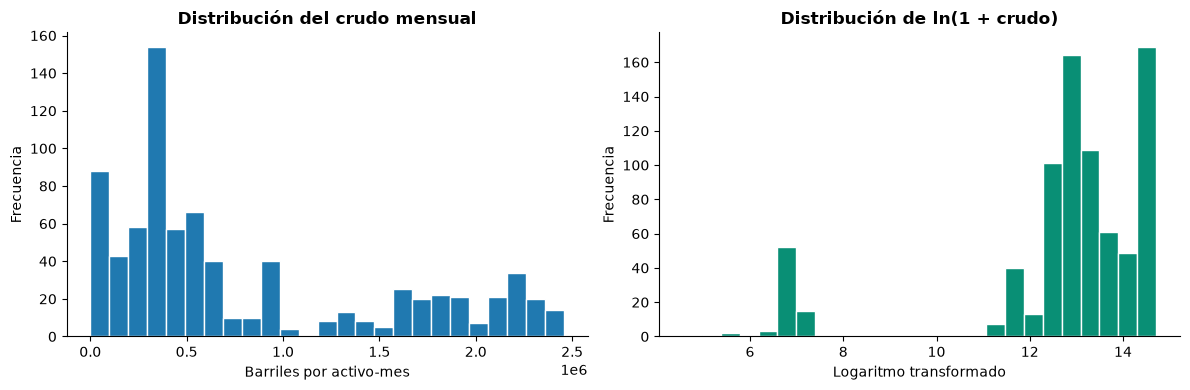

In [16]:
figuras_creadas = []
def mostrar_figura(fig, nombre):
    """Guardar y mostrar la figura que se acaba de calcular en este notebook."""
    fig.tight_layout()
    fig.savefig(FIGURAS / nombre, dpi=150, bbox_inches='tight')
    figuras_creadas.append(nombre)
    plt.show()
    plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['crudo'].dropna(), bins=25, color=AZUL, edgecolor='white')
axes[0].set(title='Distribución del crudo mensual', xlabel='Barriles por activo-mes', ylabel='Frecuencia')
axes[1].hist(df['log1p_crudo'].dropna(), bins=25, color=VERDE, edgecolor='white')
axes[1].set(title='Distribución de ln(1 + crudo)', xlabel='Logaritmo transformado', ylabel='Frecuencia')
mostrar_figura(fig, '01_distribucion.png')

### 3.3. Comparar distribuciones por activo con un diagrama de cajas
Cada caja utiliza tasas diarias del mismo activo y muestra su mediana, dispersión y extremos. Los puntos fuera de los bigotes son observaciones que merecen revisión, no errores demostrados. La escala logarítmica permite ver activos grandes y pequeños; todos los valores válidos de crudo diario de estas fuentes son positivos.

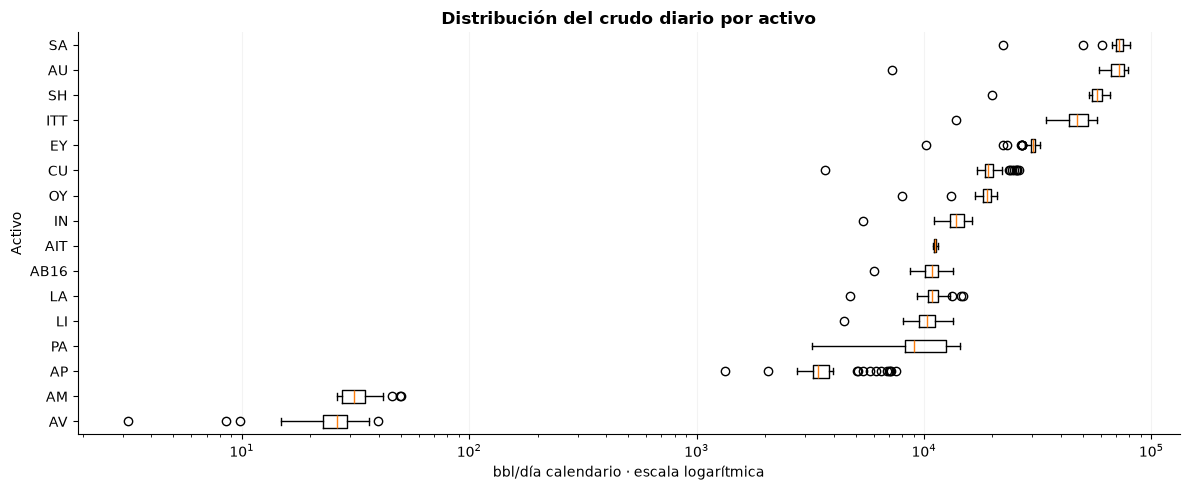

In [17]:
orden_activos = df.groupby('activo')['crudo_diario'].median().sort_values().index.tolist()
muestras = [df.loc[df['activo'].eq(a), 'crudo_diario'].dropna() for a in orden_activos]
assert all((muestra > 0).all() for muestra in muestras), 'La escala logarítmica exige valores positivos.'
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(muestras, orientation='horizontal', tick_labels=orden_activos)
ax.set_xscale('log')
ax.set(title='Distribución del crudo diario por activo', xlabel='bbl/día calendario · escala logarítmica', ylabel='Activo')
ax.grid(axis='x', alpha=.15)
mostrar_figura(fig, '02_cajas_activos.png')

## 4. Análisis bivariado y temporal · EDA 4 · T6
### 4.1. Agregar por mes sin repetir el precio ni los días
La función `serie_mensual()` se define aquí. Suma volúmenes disponibles y cuenta activos y valores válidos. `min_count=1` conserva NA si falta todo el grupo. Los días y el precio se toman una vez por mes: cada mes tiene un único precio porque ya se validó la tabla original.

Una suma de todos los activos puede cambiar por cambios en su composición; por eso se acompaña de cobertura y después se construye una cohorte fija.

,fecha,crudo,gas,n_activos,n_crudo,n_gas,dias_mes,precio_usd_barril,crudo_diario,gas_diario
0,2022-01-01,11007063.32,3254225.028,13,13,13,31,77.62,355066.558710,104975.000903
1,2022-02-01,10423601.87,3044693.435,13,13,13,28,84.66,372271.495357,108739.051250
2,2022-03-01,12017841.90,3433927.665,13,13,13,31,100.38,387672.319355,110771.860161
3,2022-04-01,11612943.16,3341905.593,13,13,13,30,94.70,387098.105333,111396.853100
4,2022-05-01,11991401.75,3489740.614,13,13,13,31,101.31,386819.411290,112572.277871


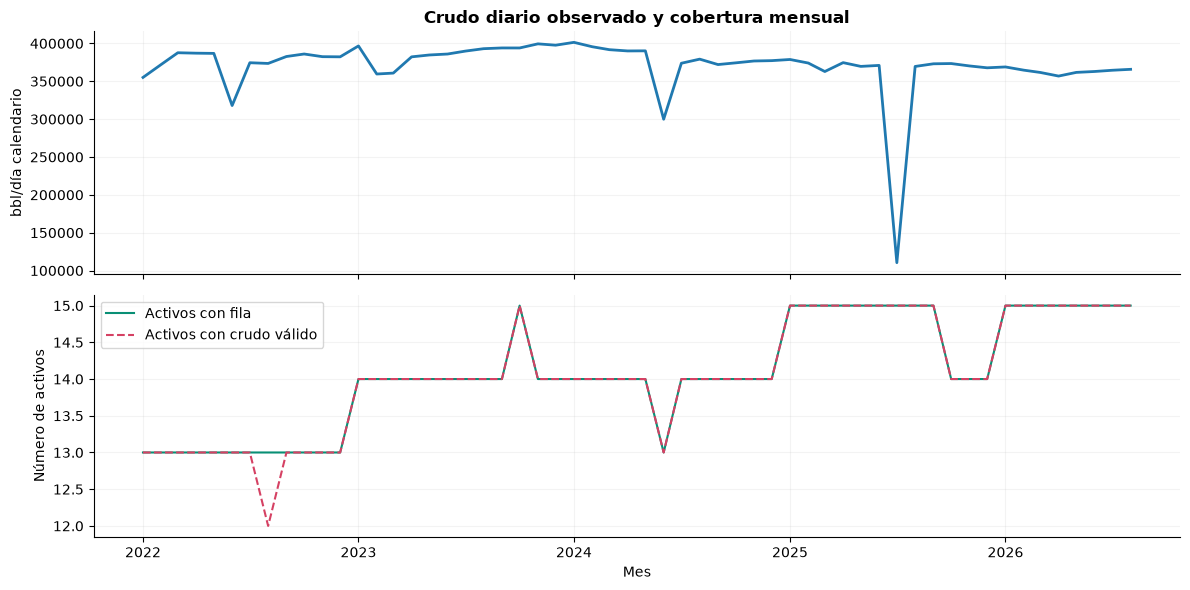

In [18]:
def serie_mensual(tabla):
    mensual = tabla.groupby('fecha').agg(
        crudo=('crudo', lambda s: s.sum(min_count=1)),
        gas=('gas', lambda s: s.sum(min_count=1)),
        n_activos=('activo', 'nunique'), n_crudo=('crudo', 'count'), n_gas=('gas', 'count'),
        dias_mes=('dias_mes', 'first'), precio_usd_barril=('precio_usd_barril', 'first'),
    ).reset_index()
    mensual['crudo_diario'] = mensual['crudo'] / mensual['dias_mes']
    mensual['gas_diario'] = mensual['gas'] / mensual['dias_mes']
    return mensual

monthly = serie_mensual(df)
display(monthly.head())
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(monthly['fecha'], monthly['crudo_diario'], color=AZUL, linewidth=2)
axes[0].set(title='Crudo diario observado y cobertura mensual', ylabel='bbl/día calendario')
axes[1].plot(monthly['fecha'], monthly['n_activos'], label='Activos con fila', color=VERDE)
axes[1].plot(monthly['fecha'], monthly['n_crudo'], label='Activos con crudo válido', color=CORAL, linestyle='--')
axes[1].set(ylabel='Número de activos', xlabel='Mes')
axes[1].legend()
for ax in axes:
    ax.grid(alpha=.15)
mostrar_figura(fig, '03_serie_cobertura.png')

### 4.2. Construir una cohorte fija y calcular cambios mensuales
Seleccionamos activos con crudo válido en todos los meses. `pct_change(fill_method=None)` calcula `(valor actual / valor anterior − 1)` sin rellenar faltantes. Lo aplicamos sobre el calendario mensual completo **antes** de quitar los pares sin precio, para evitar saltar un hueco y tratar dos meses no consecutivos como vecinos.

Un precio por mes no se convierte en muchas observaciones por repetirse entre activos. La unidad de esta asociación es un par mensual.

In [19]:
n_meses_historia = df['fecha'].nunique()
conteos = df.groupby('activo')['crudo'].count()
cohorte = sorted(conteos[conteos.eq(n_meses_historia)].index.tolist())
balanced = serie_mensual(df[df['activo'].isin(cohorte)])
assert balanced['fecha'].tolist() == list(calendario)
pares_niveles = balanced.dropna(subset=['crudo_diario', 'precio_usd_barril']).copy()
balanced['cambio_crudo_pct'] = balanced['crudo_diario'].pct_change(fill_method=None) * 100
balanced['cambio_precio_pct'] = balanced['precio_usd_barril'].pct_change(fill_method=None) * 100
changes = balanced.dropna(subset=['cambio_crudo_pct', 'cambio_precio_pct']).copy()
pearson_niveles = pares_niveles[['crudo_diario', 'precio_usd_barril']].corr().iloc[0, 1]
pearson_cambios = changes[['cambio_crudo_pct', 'cambio_precio_pct']].corr().iloc[0, 1]
spearman_cambios = changes[['cambio_crudo_pct', 'cambio_precio_pct']].corr(method='spearman').iloc[0, 1]
print('Activos de la cohorte:', ', '.join(cohorte))
display(pd.DataFrame([{
    'activos_constantes': len(cohorte), 'meses_productivos': len(balanced),
    'meses_con_precio': len(pares_niveles), 'n_cambios_pareados': len(changes),
    'Pearson_niveles': pearson_niveles, 'Pearson_cambios': pearson_cambios,
    'Spearman_cambios': spearman_cambios,
}]))

Activos de la cohorte: AM, AP, AU, CU, EY, IN, ITT, LI, OY, PA, SA


,activos_constantes,meses_productivos,meses_con_precio,n_cambios_pareados,Pearson_niveles,Pearson_cambios,Spearman_cambios
0,11,56,55,54,0.127211,0.016568,0.064227


### 4.3. Crear el gráfico de dispersión y explicar la asociación
Cada punto es un mes: X muestra el cambio del precio y Y el cambio de la producción diaria de la cohorte. Las líneas en cero ayudan a distinguir aumentos y descensos. Los valores extremos se conservan y pueden influir en Pearson; Spearman ofrece una descripción adicional basada en rangos.

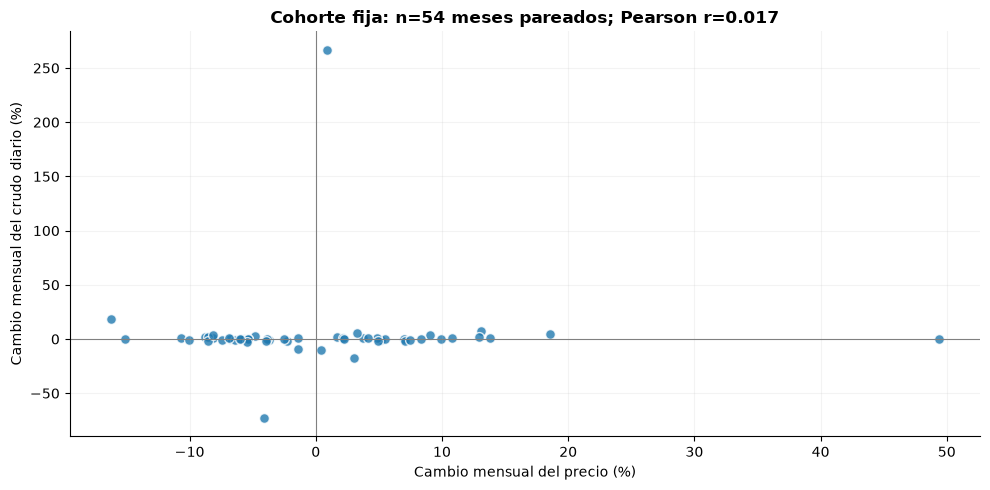

**Interpretación:** Pearson en cambios = 0.017; Spearman = 0.064. En estas fuentes no aparece una asociación lineal contemporánea fuerte. Esto no demuestra independencia, no descarta rezagos y no identifica causas operativas. El precio es una referencia agregada: multiplicarlo por producción no estima ingresos efectivos.

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(changes['cambio_precio_pct'], changes['cambio_crudo_pct'], color=AZUL, alpha=.8, edgecolor='white', s=50)
ax.axhline(0, color='gray', linewidth=.8)
ax.axvline(0, color='gray', linewidth=.8)
ax.set(title=f'Cohorte fija: n={len(changes)} meses pareados; Pearson r={pearson_cambios:.3f}',
       xlabel='Cambio mensual del precio (%)', ylabel='Cambio mensual del crudo diario (%)')
ax.grid(alpha=.15)
mostrar_figura(fig, '04_cambios_precio_produccion.png')
display(Markdown(
    f'**Interpretación:** Pearson en cambios = {pearson_cambios:.3f}; Spearman = {spearman_cambios:.3f}. '
    'En estas fuentes no aparece una asociación lineal contemporánea fuerte. '
    'Esto no demuestra independencia, no descarta rezagos y no identifica causas operativas. '
    'El precio es una referencia agregada: multiplicarlo por producción no estima ingresos efectivos.'
))

### 4.4. Programar el remuestreo por bloques · T6–T8
La siguiente función también está escrita íntegramente aquí. Toma bloques circulares de meses y selecciona juntos los valores X e Y. Se repite 2.000 veces con semilla fija. Los percentiles 2,5 y 97,5 forman un intervalo exploratorio del 95 %.

Los bloques preservan parte de la dependencia local; no garantizan estacionariedad ni cobertura estadística nominal. Se prueba longitud 3 y, como sensibilidad, 6. Con menos de 12 pares o una variable constante, la función no presenta una correlación utilizable. No se usa un p-valor que presuponga meses independientes.

In [21]:
def correlacion_por_bloques(x, y, semilla=SEED, replicas=2000, bloque=3):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if len(x) != len(y) or not (np.isfinite(x).all() and np.isfinite(y).all()):
        raise ValueError('Se necesitan pares completos de la misma longitud.')
    if len(x) < SMALL_N or np.std(x) == 0 or np.std(y) == 0:
        return {'n': len(x), 'r': None, 'ic95': None, 'bloque': bloque,
                'replicas': replicas, 'semilla': semilla}
    rng = np.random.default_rng(semilla)
    n = len(x)
    correlaciones = []
    for _ in range(replicas):
        inicios = rng.integers(0, n, size=int(np.ceil(n / bloque)))
        indices = ((inicios[:, None] + np.arange(bloque)) % n).ravel()[:n]
        if np.std(x[indices]) > 0 and np.std(y[indices]) > 0:
            correlaciones.append(np.corrcoef(x[indices], y[indices])[0, 1])
    return {'n': n, 'r': float(np.corrcoef(x, y)[0, 1]),
            'ic95': np.quantile(correlaciones, [.025, .975]).tolist(),
            'bloque': bloque, 'replicas': replicas, 'semilla': semilla}

bootstrap3 = correlacion_por_bloques(changes['cambio_crudo_pct'], changes['cambio_precio_pct'])
bootstrap6 = correlacion_por_bloques(changes['cambio_crudo_pct'], changes['cambio_precio_pct'], bloque=6)
display(pd.DataFrame([bootstrap3, bootstrap6]))
display(Markdown(
    f"**Resultado:** r = {bootstrap3['r']:.3f}, n = {bootstrap3['n']}. "
    f"Intervalo con bloques de 3 meses: [{bootstrap3['ic95'][0]:.3f}, {bootstrap3['ic95'][1]:.3f}]. "
    'El intervalo incluye cero y valores de ambos signos. La evidencia disponible no permite sostener una relación lineal fuerte.'
))

,n,r,ic95,bloque,replicas,semilla
0,54,0.016568,"[-0.20176605044229481, 0.19230747830279715]",3,2000,2026
1,54,0.016568,"[-0.20171035716959443, 0.19956742729770377]",6,2000,2026


**Resultado:** r = 0.017, n = 54. Intervalo con bloques de 3 meses: [-0.202, 0.192]. El intervalo incluye cero y valores de ambos signos. La evidencia disponible no permite sostener una relación lineal fuerte.

## 5. Interpretar la calidad encontrada · EDA 5 · T3–T4
La limpieza ya se ejecutó en las celdas 2.5–2.12. Ahora interpretamos su auditoría y construimos un mapa de cobertura. Cada celda del mapa representa un activo-mes; el color no mide producción.

Gris significa fuera de cobertura observada; ámbar, ausencia interior; coral, conflicto en una medida de un registro presente. No se imputan ceros, no se inventan nombres y no se eliminan atípicos para mejorar la apariencia de los resultados.

,anio,mes,activo,variable,valores,filas_origen,tratamiento
0,2022,8,AM,gas,713407.82 | 103.69,93|110,NA; pendiente de validar con la fuente
1,2022,8,AU,gas,310275.38 | 310050.89,95|115,NA; pendiente de validar con la fuente
2,2022,8,LA,crudo,366668.06 | 366668.05,100|112,NA; pendiente de validar con la fuente


,fecha,activo,estado,crudo_valido,gas_valido
302,2023-11-01,AV,sin registro interior,False,False
303,2023-12-01,AV,sin registro interior,False,False
304,2024-01-01,AV,sin registro interior,False,False
305,2024-02-01,AV,sin registro interior,False,False
306,2024-03-01,AV,sin registro interior,False,False
307,2024-04-01,AV,sin registro interior,False,False
308,2024-05-01,AV,sin registro interior,False,False
309,2024-06-01,AV,sin registro interior,False,False
310,2024-07-01,AV,sin registro interior,False,False
311,2024-08-01,AV,sin registro interior,False,False


**Auditoría:** 9 copias exactas adicionales; 13 filas redundantes en total; 789 claves únicas. Persisten 3 celdas conflictivas y 18 huecos interiores. Se conservaron 18 ceros de gas, 52 marcas IQR de crudo y 42 de gas. AB16 queda identificado como sin catálogo; agosto de 2026 permanece sin precio.

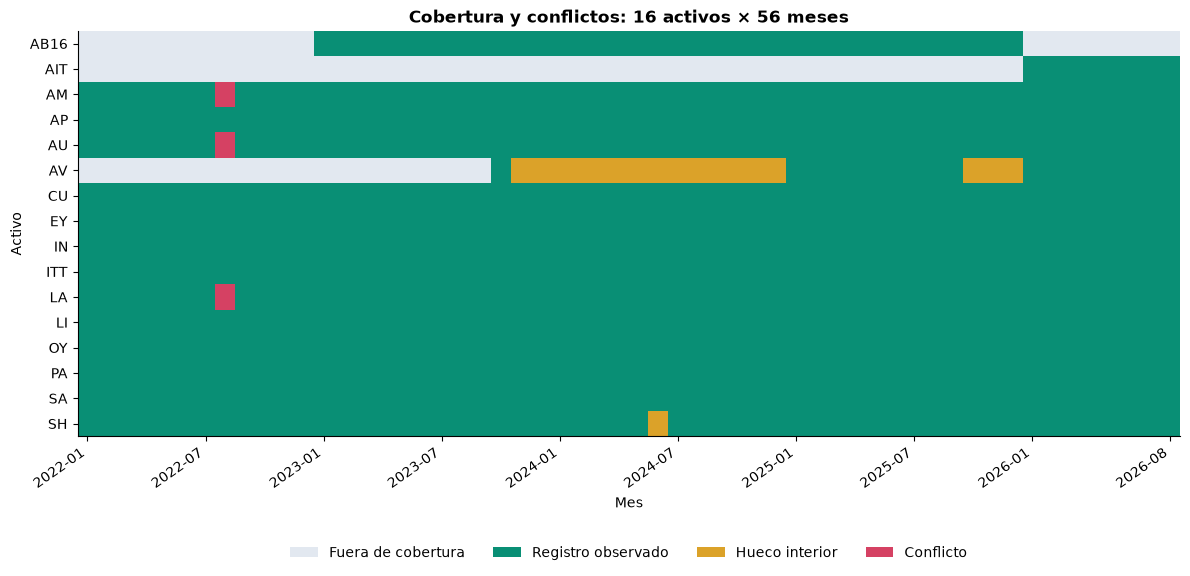

In [22]:
display(conflicts)
display(coverage.loc[coverage['estado'].eq('sin registro interior')])
display(Markdown(
    f"**Auditoría:** {audit['copias_exactas_extra']} copias exactas adicionales; "
    f"{audit['filas_redundantes']} filas redundantes en total; {len(df)} claves únicas. "
    f"Persisten {audit['celdas_conflictivas']} celdas conflictivas y {audit['huecos_interiores']} huecos interiores. "
    f"Se conservaron {audit['ceros_gas_conservados']} ceros de gas, "
    f"{audit['atipicos_crudo']} marcas IQR de crudo y {audit['atipicos_gas']} de gas. "
    'AB16 queda identificado como sin catálogo; agosto de 2026 permanece sin precio.'
))
estados = {'fuera de cobertura observada': 0, 'observado': 1, 'sin registro interior': 2}
mapa = coverage.assign(valor=coverage['estado'].map(estados)).pivot(index='activo', columns='fecha', values='valor')
for fila in df.loc[df['conflicto_crudo'] | df['conflicto_gas']].itertuples():
    mapa.loc[fila.activo, fila.fecha] = 3
colores = ['#E2E8F0', VERDE, AMBAR, CORAL]
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(mapa.to_numpy(), aspect='auto', cmap=ListedColormap(colores),
          norm=BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5], 4), interpolation='nearest')
ax.set_yticks(range(len(mapa)), mapa.index)
marcas_x = sorted(set(list(range(0, len(mapa.columns), 6)) + [len(mapa.columns)-1]))
if len(marcas_x) > 1 and marcas_x[-1] - marcas_x[-2] < 3:
    marcas_x.pop(-2)  # Evitar solapar las dos etiquetas del final.
ax.set_xticks(marcas_x, [mapa.columns[i].strftime('%Y-%m') for i in marcas_x], rotation=35, ha='right')
ax.set(title=f'Cobertura y conflictos: {len(mapa)} activos × {len(mapa.columns)} meses', xlabel='Mes', ylabel='Activo')
ax.legend(handles=[Patch(facecolor=c, label=t) for c, t in zip(colores,
          ['Fuera de cobertura', 'Registro observado', 'Hueco interior', 'Conflicto'])],
          loc='upper center', bbox_to_anchor=(.5, -.24), ncol=4, frameon=False)
mostrar_figura(fig, '05_mapa_calidad.png')

## 6. Segmentación y comparación · EDA 6 · T7
### 6.1. Agrupar por activo y año con n explícito
`size` cuenta filas y `count` valores no vacíos. La media mensual de tasas diarias y su mediana son resúmenes de distribución; la tasa del período que usaremos para comparar años se calcula aparte como volumen total dividido entre días del período.

**n < 12** activa una precaución por cobertura menor a un ciclo anual. No es un umbral universal de significación ni garantiza que con 12 meses las observaciones sean independientes.

In [23]:
groups = df.groupby(['activo', 'nombre_activo', 'anio'], observed=True).agg(
    n_registros=('fecha', 'size'), n_crudo=('crudo', 'count'), n_gas=('gas', 'count'),
    n_precio=('precio_usd_barril', 'count'),
    crudo_total=('crudo', lambda s: s.sum(min_count=1)),
    media_crudo_diario=('crudo_diario', 'mean'), mediana_crudo_diario=('crudo_diario', 'median'),
    gas_total=('gas', lambda s: s.sum(min_count=1)),
).reset_index()
groups['grupo_pequeno'] = groups['n_crudo'] < SMALL_N
with pd.option_context('display.max_rows', None):
    display(groups)

,activo,nombre_activo,anio,n_registros,n_crudo,n_gas,n_precio,crudo_total,media_crudo_diario,mediana_crudo_diario,gas_total,grupo_pequeno
0,AB16,AB16 (sin catálogo),2023,12,12,12,12,3.800027e+06,10413.330339,10102.817903,1040004.840,False
1,AB16,AB16 (sin catálogo),2024,12,12,12,12,3.939064e+06,10762.924234,10694.943226,1032896.350,False
2,AB16,AB16 (sin catálogo),2025,12,12,12,12,4.030420e+06,11051.526921,11417.401683,1063770.490,False
3,AIT,Amo-Iro-Tivacuno,2026,8,8,8,7,2.716245e+06,11178.491388,11200.132968,800088.240,True
4,AM,Amistad,2022,12,12,11,12,1.503885e+04,41.248130,40.343801,5107489.280,False
5,AM,Amistad,2023,12,12,12,12,1.113435e+04,30.493621,28.819343,7692316.670,False
6,AM,Amistad,2024,12,12,12,12,1.214920e+04,33.194821,33.668649,7429507.870,False
7,AM,Amistad,2025,12,12,12,12,1.047372e+04,28.710048,28.026177,6719531.590,False
8,AM,Amistad,2026,8,8,8,7,6.703130e+03,27.605731,26.868237,5566119.621,True
9,AP,Apaika,2022,12,12,12,12,1.268469e+06,3473.379662,3437.069700,148599.291,False


### 6.2. Comparar los mismos meses y los mismos activos
El último año observado llega hasta agosto. Seleccionamos enero-agosto de ambos años y conservamos solo activos con crudo válido en todos esos meses. Cada activo tiene su n actual y anterior.

Para el total de la cohorte, **los días se cuentan una sola vez por mes**, no una vez por activo. Porcentajes de varios activos no se suman ni se promedian sin considerar el volumen.

In [24]:
anio_actual = int(df['anio'].max())
mes_corte = int(df.loc[df['anio'].eq(anio_actual), 'mes'].max())
actual = df[df['anio'].eq(anio_actual) & df['mes'].le(mes_corte)].copy()
anterior = df[df['anio'].eq(anio_actual - 1) & df['mes'].le(mes_corte)].copy()
n_actual = actual.groupby('activo')['crudo'].count()
n_anterior = anterior.groupby('activo')['crudo'].count()
comunes = sorted(set(n_actual[n_actual.eq(mes_corte)].index) & set(n_anterior[n_anterior.eq(mes_corte)].index))
comparaciones = []
for activo in comunes:
    ga = actual[actual['activo'].eq(activo)]
    gb = anterior[anterior['activo'].eq(activo)]
    tasa_actual = ga['crudo'].sum(min_count=1) / ga['dias_mes'].sum()
    tasa_anterior = gb['crudo'].sum(min_count=1) / gb['dias_mes'].sum()
    comparaciones.append({'activo': activo, 'n_actual': len(ga), 'n_anterior': len(gb),
                          'diario_actual': tasa_actual, 'diario_anterior': tasa_anterior,
                          'cambio_pct': 100*(tasa_actual/tasa_anterior-1) if tasa_anterior > 0 else np.nan,
                          'cambio_diario': tasa_actual-tasa_anterior})
comparison = pd.DataFrame(comparaciones).sort_values('cambio_diario').reset_index(drop=True)
actual_comun = actual[actual['activo'].isin(comunes)].copy()
anterior_comun = anterior[anterior['activo'].isin(comunes)].copy()
dias_actual = actual_comun[['fecha', 'dias_mes']].drop_duplicates()['dias_mes'].sum()
dias_anterior = anterior_comun[['fecha', 'dias_mes']].drop_duplicates()['dias_mes'].sum()
diario_actual_comun = actual_comun['crudo'].sum() / dias_actual
diario_anterior_comun = anterior_comun['crudo'].sum() / dias_anterior
cambio_comparable_pct = 100*(diario_actual_comun/diario_anterior_comun - 1)
print('Activos comparables:', ', '.join(comunes))
print('Días actuales/anterior:', dias_actual, '/', dias_anterior)
print('n activo-mes actual/anterior:', len(actual_comun), '/', len(anterior_comun))
display(comparison)

Activos comparables: AM, AP, AU, AV, CU, EY, IN, ITT, LA, LI, OY, PA, SA, SH
Días actuales/anterior: 243 / 243
n activo-mes actual/anterior: 112 / 112


,activo,n_actual,n_anterior,diario_actual,diario_anterior,cambio_pct,cambio_diario
0,IN,8,8,12555.692140,13393.361111,-6.254360,-837.668971
1,AV,8,8,22.618889,26.417119,-14.377913,-3.798230
2,AM,8,8,27.584897,28.546144,-3.367344,-0.961247
3,AU,8,8,61618.656296,60748.374527,1.432601,870.281770
4,CU,8,8,17751.069012,16522.991728,7.432536,1228.077284
5,ITT,8,8,41540.465263,40126.357321,3.524137,1414.107942
6,PA,8,8,13002.011811,11340.791852,14.648183,1661.219959
7,LI,8,8,10411.597407,8634.504733,20.581292,1777.092675
8,EY,8,8,29269.917152,27464.491663,6.573672,1805.425490
9,LA,8,8,12178.456831,10248.306996,18.833841,1930.149835


### 6.3. Graficar la comparación conjunta
Usamos barras que parten de cero, con la misma unidad y el mismo período. El título especifica n y cobertura. Un aumento de esta tasa es un cambio descriptivo del volumen por día; su estabilidad se comprobará en la sección 6.6.

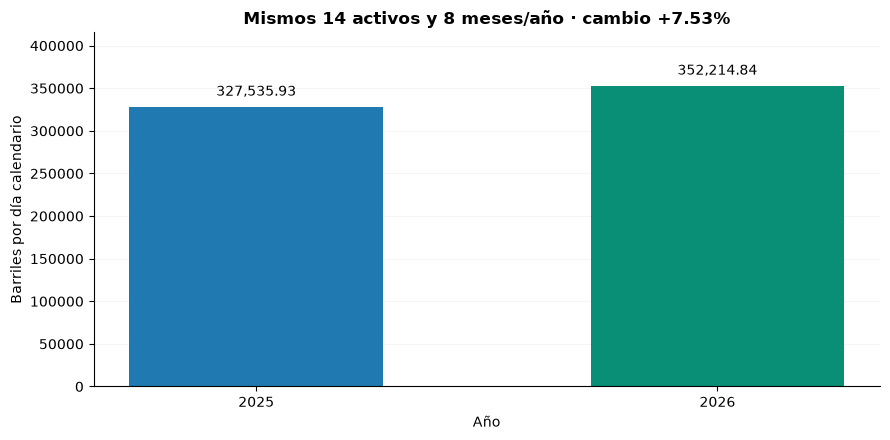

In [25]:
fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.bar([str(anio_actual-1), str(anio_actual)], [diario_anterior_comun, diario_actual_comun], color=[AZUL, VERDE], width=.55)
ax.bar_label(barras, labels=[f'{diario_anterior_comun:,.2f}', f'{diario_actual_comun:,.2f}'], padding=6)
ax.set(title=f'Mismos {len(comunes)} activos y {mes_corte} meses/año · cambio {cambio_comparable_pct:+.2f}%',
       ylabel='Barriles por día calendario', xlabel='Año', ylim=(0, max(diario_actual_comun, diario_anterior_comun)*1.18))
ax.grid(axis='y', alpha=.12)
ax.set_axisbelow(True)
mostrar_figura(fig, '06_comparacion_conjunta.png')

### 6.4. Identificar el impacto absoluto y relativo por activo
Las barras muestran bbl/día ganados o perdidos, y las etiquetas añaden el porcentaje. Esto evita priorizar únicamente un porcentaje grande de un activo de volumen pequeño. Se conserva la tabla anterior para consultar diferencias demasiado pequeñas para verse a esta escala.

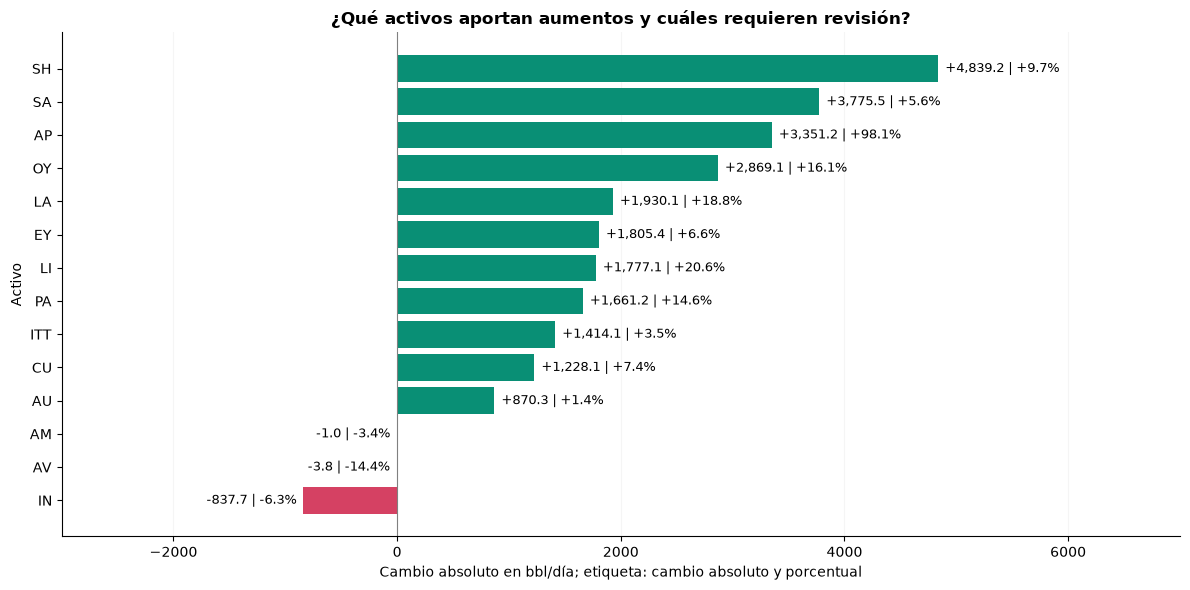

Mayor descenso absoluto: IN | bbl/día: -837.67
Activos con aumento: 11 | con descenso: 3


In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
colores_impacto = [VERDE if x >= 0 else CORAL for x in comparison['cambio_diario']]
barras = ax.barh(comparison['activo'], comparison['cambio_diario'], color=colores_impacto)
etiquetas = [f'{r.cambio_diario:+,.1f} | {r.cambio_pct:+.1f}%' for r in comparison.itertuples()]
ax.bar_label(barras, labels=etiquetas, padding=5, fontsize=9)
ax.set(xlim=(-3000, 7000), title='¿Qué activos aportan aumentos y cuáles requieren revisión?',
       xlabel='Cambio absoluto en bbl/día; etiqueta: cambio absoluto y porcentual', ylabel='Activo')
ax.axvline(0, color='gray', linewidth=.8)
ax.grid(axis='x', alpha=.12)
ax.set_axisbelow(True)
mostrar_figura(fig, '07_impacto_activos.png')
mayor_caida = comparison.iloc[0]
print('Mayor descenso absoluto:', mayor_caida['activo'], '| bbl/día:', round(mayor_caida['cambio_diario'], 2))
print('Activos con aumento:', int(comparison['cambio_diario'].gt(0).sum()),
      '| con descenso:', int(comparison['cambio_diario'].lt(0).sum()))

### 6.5. Medir concentración del volumen observado
Aquí se usa todo el período actual observado, incluidos los activos que no entraron en la comparación interanual. La participación es volumen del activo dividido entre volumen observado total. No mide rentabilidad, reservas o probabilidad de falla.

,crudo_bbl,participacion_pct,n_meses_crudo
activo,,,
AIT,2.716245e+06,3.076001,8
AM,6.703130e+03,0.007591,8
AP,1.644230e+06,1.862001,8
AU,1.497333e+07,16.956488,8
AV,5.496390e+03,0.006224,8
CU,4.313510e+06,4.884816,8
EY,7.112590e+06,8.054622,8
IN,3.051033e+06,3.455130,8
ITT,1.009433e+07,11.431285,8


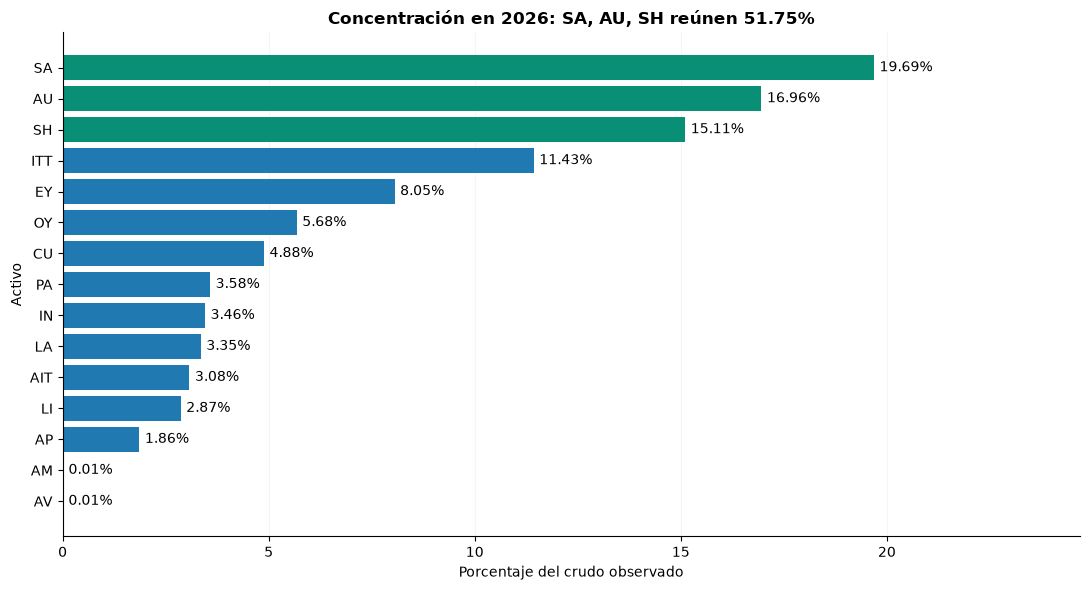

In [27]:
volumenes = actual.groupby('activo')['crudo'].sum(min_count=1).sort_values(ascending=False)
participaciones = 100*volumenes/volumenes.sum()
top3 = volumenes.head(3).index.tolist()
top3_pct = float(participaciones.loc[top3].sum())
dias_periodo_actual = actual[['fecha', 'dias_mes']].drop_duplicates()['dias_mes'].sum()
crudo_actual = float(volumenes.sum())
concentracion = pd.DataFrame({'crudo_bbl': volumenes, 'participacion_pct': participaciones,
                             'n_meses_crudo': actual.groupby('activo')['crudo'].count()})
display(concentracion)
grafico = participaciones.sort_values()
fig, ax = plt.subplots(figsize=(11, 6))
barras = ax.barh(grafico.index, grafico.values, color=[VERDE if a in top3 else AZUL for a in grafico.index])
ax.bar_label(barras, labels=[f'{v:.2f}%' for v in grafico.values], padding=4)
ax.set(title=f'Concentración en {anio_actual}: {", ".join(top3)} reúnen {top3_pct:.2f}%',
       xlabel='Porcentaje del crudo observado', ylabel='Activo', xlim=(0, grafico.max()+5))
ax.grid(axis='x', alpha=.12)
ax.set_axisbelow(True)
mostrar_figura(fig, '08_concentracion.png')

### 6.6. Comprobar si el aumento depende de un mes excepcional
La comparación conjunta puede ocultar diferencias mensuales. Comparamos la misma cohorte en cada mes y agregamos una sensibilidad: excluir **julio de ambos años**, manteniendo los demás meses y días equivalentes.

Esta comprobación se añadió al profundizar en la toma de decisiones. No borra julio de las fuentes ni reemplaza la comparación principal. Permite separar un aumento acumulado de una mejora sostenida y evita atribuir causas que no están en los datos.

,crudo_actual,dias_actual,crudo_anterior,dias_anterior,diario_actual,diario_anterior,cambio_pct
mes,,,,,,,
1,11078388.68,31,1.138259e+07,31,357367.376774,367180.424839,-2.672541
2,9894371.99,28,1.014835e+07,28,353370.428214,362440.911071,-2.502610
3,10863693.33,31,1.089286e+07,31,350441.720323,351382.592903,-0.267763
4,10378589.72,30,1.090506e+07,30,345952.990667,363501.987333,-4.827758
5,10872974.90,31,1.111681e+07,31,350741.125806,358606.743548,-2.193383
6,10551160.56,30,1.079734e+07,30,351705.352000,359911.212333,-2.279968
7,10958040.57,31,3.236018e+06,31,353485.179677,104387.693548,238.627254
8,10990985.98,31,1.111221e+07,31,354547.934839,358458.300419,-1.090884


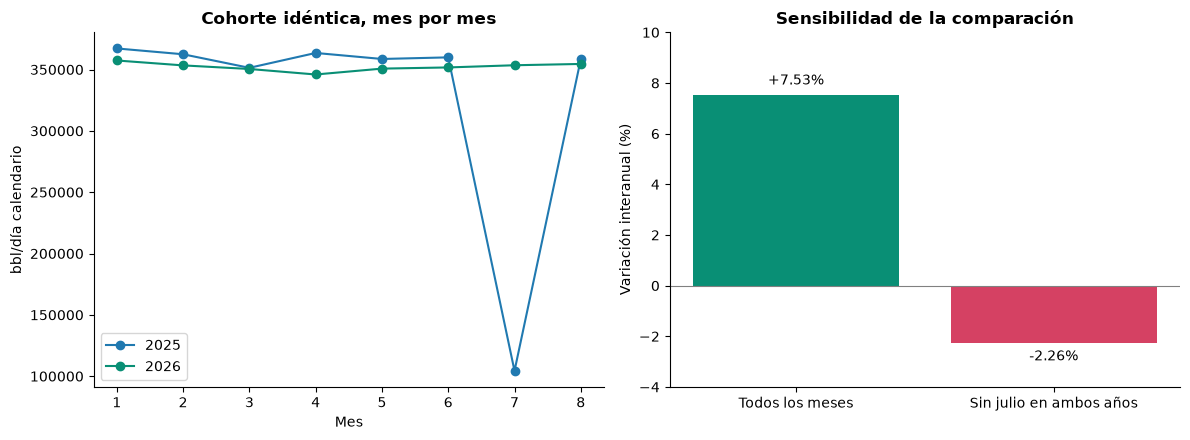

**Lectura:** el cambio conjunto es +7.53%, pero 7 de 8 meses muestran descenso. Sin julio en ambos años, el cambio es -2.26%: n=7 meses por activo/año y 212 días actuales. El resultado depende de la baja base de julio de 2025. Antes de afirmar mejora sostenida, se debe conciliar ese mes y consultar información operativa.

In [28]:
mensual_actual = actual_comun.groupby('mes').agg(crudo_actual=('crudo', 'sum'), dias_actual=('dias_mes', 'first'))
mensual_anterior = anterior_comun.groupby('mes').agg(crudo_anterior=('crudo', 'sum'), dias_anterior=('dias_mes', 'first'))
comparacion_meses = mensual_actual.join(mensual_anterior, how='inner')
comparacion_meses['diario_actual'] = comparacion_meses['crudo_actual']/comparacion_meses['dias_actual']
comparacion_meses['diario_anterior'] = comparacion_meses['crudo_anterior']/comparacion_meses['dias_anterior']
comparacion_meses['cambio_pct'] = 100*(comparacion_meses['diario_actual']/comparacion_meses['diario_anterior']-1)
sin_julio = comparacion_meses.loc[comparacion_meses.index != 7]
tasa_sin_julio_actual = sin_julio['crudo_actual'].sum()/sin_julio['dias_actual'].sum()
tasa_sin_julio_anterior = sin_julio['crudo_anterior'].sum()/sin_julio['dias_anterior'].sum()
cambio_sin_julio_pct = 100*(tasa_sin_julio_actual/tasa_sin_julio_anterior-1)
meses_en_descenso = int(comparacion_meses['cambio_pct'].lt(0).sum())
display(comparacion_meses)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(comparacion_meses.index, comparacion_meses['diario_anterior'], marker='o', color=AZUL, label=str(anio_actual-1))
axes[0].plot(comparacion_meses.index, comparacion_meses['diario_actual'], marker='o', color=VERDE, label=str(anio_actual))
axes[0].set(title='Cohorte idéntica, mes por mes', xlabel='Mes', ylabel='bbl/día calendario', xticks=comparacion_meses.index)
axes[0].legend()
barras = axes[1].bar(['Todos los meses', 'Sin julio en ambos años'], [cambio_comparable_pct, cambio_sin_julio_pct], color=[VERDE, CORAL])
axes[1].bar_label(barras, labels=[f'{cambio_comparable_pct:+.2f}%', f'{cambio_sin_julio_pct:+.2f}%'], padding=5)
axes[1].axhline(0, color='gray', linewidth=.8)
axes[1].set(title='Sensibilidad de la comparación', ylabel='Variación interanual (%)', ylim=(-4, 10))
mostrar_figura(fig, '09_sensibilidad_julio.png')
display(Markdown(
    f'**Lectura:** el cambio conjunto es {cambio_comparable_pct:+.2f}%, pero {meses_en_descenso} de '
    f'{len(comparacion_meses)} meses muestran descenso. Sin julio en ambos años, el cambio es '
    f'{cambio_sin_julio_pct:+.2f}%: n={len(sin_julio)} meses por activo/año y '
    f'{int(sin_julio["dias_actual"].sum())} días actuales. El resultado depende de la baja base de julio de 2025. '
    'Antes de afirmar mejora sostenida, se debe conciliar ese mes y consultar información operativa.'
))

## 7. Hallazgos, cinco preguntas y decisiones · EDA 7
### 7.1. Responder la pregunta principal
Las respuestas se construyen con las variables calculadas en este notebook. Las referencias a figuras indican celdas anteriores del mismo archivo, no documentos externos.

In [29]:
display(Markdown(
    '**¿Qué mejoras y oportunidades se identifican mediante las variaciones?** '
    f'La cohorte comparable aumenta {cambio_comparable_pct:.2f}% en el acumulado, pero la sensibilidad sin julio '
    f'es {cambio_sin_julio_pct:.2f}%. No se puede afirmar una mejora sostenida solo con el acumulado. '
    f'La revisión prioritaria por pérdida absoluta corresponde a {mayor_caida["activo"]}; '
    f'la continuidad de {", ".join(top3)} merece atención por su {top3_pct:.2f}% del volumen. '
    'Conciliar datos y consultar causas operativas son oportunidades verificables. '
    'No se demuestra eficiencia, rentabilidad ni el efecto de una intervención.'
))
preguntas = [
    {'numero': 1, 'pregunta': '¿Mejoró la producción al comparar los mismos activos y meses?',
     'justificacion': f'Basada en los datos: {len(comunes)} activos con {mes_corte} meses válidos por año; {len(actual_comun)} activo-mes actuales y {int(dias_actual)} días.',
     'respuesta': f'La tasa pasa de {diario_anterior_comun:,.2f} a {diario_actual_comun:,.2f} bbl/día ({cambio_comparable_pct:+.2f}%). Sin julio en ambos años: {cambio_sin_julio_pct:+.2f}%.',
     'grafica': '6.3: comparación conjunta; 6.6: sensibilidad mensual.',
     'limite': 'n=8 por activo y año; n=7 en la sensibilidad. Mayor tasa no equivale a eficiencia ni a mejora sostenida.'},
    {'numero': 2, 'pregunta': '¿Qué activos conviene revisar por sus descensos?',
     'justificacion': 'Basada en los datos: cada activo comparable tiene un cambio absoluto, un porcentaje y n de ambos períodos.',
     'respuesta': f'{mayor_caida["activo"]} tiene la mayor pérdida absoluta: {mayor_caida["cambio_diario"]:+,.2f} bbl/día ({mayor_caida["cambio_pct"]:+.2f}%).',
     'grafica': '6.4: impacto absoluto y porcentual por activo.',
     'limite': 'La prioridad considera volumen. No se conocen costos, paradas ni causas del descenso.'},
    {'numero': 3, 'pregunta': '¿Dónde se concentra el volumen observado?',
     'justificacion': f'Basada en los datos: {len(actual)} registros del período actual, distribuidos en {actual["activo"].nunique()} activos.',
     'respuesta': f'{", ".join(top3)} concentran {top3_pct:.2f}% de {crudo_actual:,.2f} barriles observados.',
     'grafica': '6.5: participación por activo.',
     'limite': 'Esta selección incluye 15 activos y difiere de los 14 comparables. Concentración no mide riesgo de falla.'},
    {'numero': 4, 'pregunta': '¿Los cambios del precio acompañan los cambios de producción?',
     'justificacion': f'Basada en los datos: {len(cohorte)} activos constantes y {len(changes)} cambios mensuales pareados; un precio por mes.',
     'respuesta': f'Pearson={pearson_cambios:.3f}; Spearman={spearman_cambios:.3f}. Intervalo exploratorio: [{bootstrap3["ic95"][0]:.3f}, {bootstrap3["ic95"][1]:.3f}].',
     'grafica': '4.3: dispersión; 4.4: remuestreo e intervalo.',
     'limite': 'La asociación es débil en estas fuentes. No demuestra independencia, ausencia de rezagos ni causalidad.'},
    {'numero': 5, 'pregunta': '¿Qué calidad debe revisarse antes de declarar una mejora real?',
     'justificacion': f'Basada en los datos: {len(conflicts)} celdas conflictivas, {audit["huecos_interiores"]} huecos y {audit["filas_sin_catalogo"]} filas sin nombre validado.',
     'respuesta': 'Conciliar crudo de LA y gas de AM/AU en agosto 2022; revisar ausencias, AB16 sin catálogo y agosto 2026 sin precio.',
     'grafica': '5: mapa de calidad y tablas de auditoría.',
     'limite': 'No rellenar ceros, inventar equivalencias ni eliminar extremos para que el resultado parezca mejor.'},
]
for p in preguntas:
    display(Markdown(f"### Pregunta {p['numero']}. {p['pregunta']}\n\n"
                     f"**Justificación:** {p['justificacion']}\n\n**Respuesta:** {p['respuesta']}\n\n"
                     f"**Gráfica en este archivo:** {p['grafica']}\n\n**Límite:** {p['limite']}"))

**¿Qué mejoras y oportunidades se identifican mediante las variaciones?** La cohorte comparable aumenta 7.53% en el acumulado, pero la sensibilidad sin julio es -2.26%. No se puede afirmar una mejora sostenida solo con el acumulado. La revisión prioritaria por pérdida absoluta corresponde a IN; la continuidad de SA, AU, SH merece atención por su 51.75% del volumen. Conciliar datos y consultar causas operativas son oportunidades verificables. No se demuestra eficiencia, rentabilidad ni el efecto de una intervención.

### Pregunta 1. ¿Mejoró la producción al comparar los mismos activos y meses?

**Justificación:** Basada en los datos: 14 activos con 8 meses válidos por año; 112 activo-mes actuales y 243 días.

**Respuesta:** La tasa pasa de 327,535.93 a 352,214.84 bbl/día (+7.53%). Sin julio en ambos años: -2.26%.

**Gráfica en este archivo:** 6.3: comparación conjunta; 6.6: sensibilidad mensual.

**Límite:** n=8 por activo y año; n=7 en la sensibilidad. Mayor tasa no equivale a eficiencia ni a mejora sostenida.

### Pregunta 2. ¿Qué activos conviene revisar por sus descensos?

**Justificación:** Basada en los datos: cada activo comparable tiene un cambio absoluto, un porcentaje y n de ambos períodos.

**Respuesta:** IN tiene la mayor pérdida absoluta: -837.67 bbl/día (-6.25%).

**Gráfica en este archivo:** 6.4: impacto absoluto y porcentual por activo.

**Límite:** La prioridad considera volumen. No se conocen costos, paradas ni causas del descenso.

### Pregunta 3. ¿Dónde se concentra el volumen observado?

**Justificación:** Basada en los datos: 120 registros del período actual, distribuidos en 15 activos.

**Respuesta:** SA, AU, SH concentran 51.75% de 88,304,451.13 barriles observados.

**Gráfica en este archivo:** 6.5: participación por activo.

**Límite:** Esta selección incluye 15 activos y difiere de los 14 comparables. Concentración no mide riesgo de falla.

### Pregunta 4. ¿Los cambios del precio acompañan los cambios de producción?

**Justificación:** Basada en los datos: 11 activos constantes y 54 cambios mensuales pareados; un precio por mes.

**Respuesta:** Pearson=0.017; Spearman=0.064. Intervalo exploratorio: [-0.202, 0.192].

**Gráfica en este archivo:** 4.3: dispersión; 4.4: remuestreo e intervalo.

**Límite:** La asociación es débil en estas fuentes. No demuestra independencia, ausencia de rezagos ni causalidad.

### Pregunta 5. ¿Qué calidad debe revisarse antes de declarar una mejora real?

**Justificación:** Basada en los datos: 3 celdas conflictivas, 18 huecos y 36 filas sin nombre validado.

**Respuesta:** Conciliar crudo de LA y gas de AM/AU en agosto 2022; revisar ausencias, AB16 sin catálogo y agosto 2026 sin precio.

**Gráfica en este archivo:** 5: mapa de calidad y tablas de auditoría.

**Límite:** No rellenar ceros, inventar equivalencias ni eliminar extremos para que el resultado parezca mejor.

### 7.2. Convertir resultados en acciones verificables
Cada decisión incluye evidencia, acción, responsable, indicador y límite. Los plazos y metas son propuestas de gestión; no son normas técnicas ni resultados estadísticos. El notebook no ejecuta acciones operativas.

In [30]:
decisiones = [
    {'decision': 'Validar el efecto de la base de julio 2025',
     'evidencia': f'Acumulado {cambio_comparable_pct:+.2f}%; sin julio {cambio_sin_julio_pct:+.2f}%; {meses_en_descenso}/8 meses caen.',
     'accion': 'Conciliar julio 2025 con medición y bitácoras en 30 días.',
     'responsable': 'Planificación y supervisión de medición.',
     'indicador': 'Cambio con/sin julio y proporción de registros de julio conciliados; meta de revisión: 100%.',
     'limite': 'El plazo y meta son propuestas; no se conoce la causa de la baja base.'},
    {'decision': 'Investigar la mayor caída absoluta',
     'evidencia': f'{mayor_caida["activo"]}: {mayor_caida["cambio_diario"]:+,.2f} bbl/día; n=8 por año.',
     'accion': 'Revisar disponibilidad, paradas y conciliación de los ocho meses en 30 días.',
     'responsable': 'Ingeniería de producción del activo.',
     'indicador': 'Brecha interanual de bbl/día y meses conciliados; meta de revisión: 8 de 8.',
     'limite': 'No atribuir a fallas o agotamiento sin información operativa.'},
    {'decision': 'Priorizar continuidad de los tres mayores aportantes',
     'evidencia': f'{", ".join(top3)} concentran {top3_pct:.2f}% del volumen actual; n=8 por activo.',
     'accion': 'Revisar mensualmente contingencias y disponibilidad antes de reasignar recursos.',
     'responsable': 'Coordinación de operaciones y mantenimiento.',
     'indicador': 'Participación y tasa diaria; revisión propuesta si cae más de 5% en períodos equivalentes.',
     'limite': '5% es un criterio propuesto. No hay datos de costos, seguridad o reservas para recomendar inversiones.'},
    {'decision': 'Resolver brechas antes de certificar resultados',
     'evidencia': f'{len(conflicts)} celdas conflictivas y {audit["huecos_interiores"]} huecos interiores.',
     'accion': 'Conciliar conflictos, confirmar cobertura y completar catálogo y precio faltantes.',
     'responsable': 'Administrador de datos y supervisor de medición.',
     'indicador': 'Pendientes confirmados: meta 0 antes de certificar; catálogo: meta 100% validado.',
     'limite': 'No imputar ceros ni inventar datos para cumplir la meta; diferenciar faltante de error.'},
    {'decision': 'Usar precio como contexto, no como única meta productiva',
     'evidencia': f'r={pearson_cambios:.3f}, n={len(changes)} pares; intervalo incluye cero.',
     'accion': 'Actualizar la comparación al recibir nuevos meses e incorporar variables operativas.',
     'responsable': 'Analista de planificación y analista comercial.',
     'indicador': 'n de pares y cobertura de la cohorte; no cuantificar con n<12.',
     'limite': 'No es un pronóstico ni un efecto causal; precio por producción no representa ingreso efectivo.'},
]
for numero, decision in enumerate(decisiones, 1):
    display(Markdown(f"### Decisión {numero}. {decision['decision']}\n\n" +
                    '\n\n'.join(f"**{clave.capitalize()}:** {valor}" for clave, valor in decision.items() if clave != 'decision')))

### Decisión 1. Validar el efecto de la base de julio 2025

**Evidencia:** Acumulado +7.53%; sin julio -2.26%; 7/8 meses caen.

**Accion:** Conciliar julio 2025 con medición y bitácoras en 30 días.

**Responsable:** Planificación y supervisión de medición.

**Indicador:** Cambio con/sin julio y proporción de registros de julio conciliados; meta de revisión: 100%.

**Limite:** El plazo y meta son propuestas; no se conoce la causa de la baja base.

### Decisión 2. Investigar la mayor caída absoluta

**Evidencia:** IN: -837.67 bbl/día; n=8 por año.

**Accion:** Revisar disponibilidad, paradas y conciliación de los ocho meses en 30 días.

**Responsable:** Ingeniería de producción del activo.

**Indicador:** Brecha interanual de bbl/día y meses conciliados; meta de revisión: 8 de 8.

**Limite:** No atribuir a fallas o agotamiento sin información operativa.

### Decisión 3. Priorizar continuidad de los tres mayores aportantes

**Evidencia:** SA, AU, SH concentran 51.75% del volumen actual; n=8 por activo.

**Accion:** Revisar mensualmente contingencias y disponibilidad antes de reasignar recursos.

**Responsable:** Coordinación de operaciones y mantenimiento.

**Indicador:** Participación y tasa diaria; revisión propuesta si cae más de 5% en períodos equivalentes.

**Limite:** 5% es un criterio propuesto. No hay datos de costos, seguridad o reservas para recomendar inversiones.

### Decisión 4. Resolver brechas antes de certificar resultados

**Evidencia:** 3 celdas conflictivas y 18 huecos interiores.

**Accion:** Conciliar conflictos, confirmar cobertura y completar catálogo y precio faltantes.

**Responsable:** Administrador de datos y supervisor de medición.

**Indicador:** Pendientes confirmados: meta 0 antes de certificar; catálogo: meta 100% validado.

**Limite:** No imputar ceros ni inventar datos para cumplir la meta; diferenciar faltante de error.

### Decisión 5. Usar precio como contexto, no como única meta productiva

**Evidencia:** r=0.017, n=54 pares; intervalo incluye cero.

**Accion:** Actualizar la comparación al recibir nuevos meses e incorporar variables operativas.

**Responsable:** Analista de planificación y analista comercial.

**Indicador:** n de pares y cobertura de la cohorte; no cuantificar con n<12.

**Limite:** No es un pronóstico ni un efecto causal; precio por producción no representa ingreso efectivo.

## 8. Reproducibilidad, verificaciones y exportación · T8
### 8.1. Comprobar que la ejecución conserva las reglas y reproduce la entrega
Estos controles se ejecutan; no son una lista de comprobación manual. Primero validan reglas (unicidad, trazabilidad y calendario). Después contrastan los resultados esperados para **estas tres copias de fuentes**, cuyas huellas ya se verificaron. Si se cambia deliberadamente el conjunto de datos, también deben revisarse estos resultados de referencia.

Repetimos el remuestreo con la misma semilla para comprobar que produce el mismo intervalo. Los controles de n pequeño y variable constante verifican que la función no emita resultados engañosos.

In [31]:
comprobaciones = {
    'Una fila por activo-mes': not df.duplicated(KEY).any(),
    'Se conservan todas las claves originales': len(df) == len(d[KEY].drop_duplicates()),
    'Se trazan todas las filas originales': int(df['n_filas_origen'].sum()) == len(raw),
    'Las fuentes mantienen 802 filas y 789 claves': len(raw) == 802 and len(df) == 789,
    'Se mantienen 1 crudo y 2 gases faltantes': df['crudo'].isna().sum() == 1 and df['gas'].isna().sum() == 2,
    'Tres celdas conflictivas': len(conflicts) == 3,
    'Se mantienen 18 ceros legítimos de gas': int(df['gas'].eq(0).sum()) == 18,
    '18 huecos internos': audit['huecos_interiores'] == 18,
    '52 y 42 marcas IQR conservadas': audit['atipicos_crudo'] == 52 and audit['atipicos_gas'] == 42,
    'El calendario incluye febrero bisiesto': df.loc[df['fecha'].eq(pd.Timestamp('2024-02-01')), 'dias_mes'].eq(29).all(),
    'Un precio por mes': not prices['fecha'].duplicated().any(),
    'Agosto 2026 sigue sin precio': df.loc[df['fecha'].eq(pd.Timestamp('2026-08-01')), 'precio_usd_barril'].isna().all(),
    'Comparación: 14 activos y 112 filas por año': len(comunes) == 14 and len(actual_comun) == len(anterior_comun) == 112,
    'Días sin duplicar por activo': dias_actual == dias_anterior == 243,
    'Volumen 2026 de referencia': np.isclose(crudo_actual, 88304451.13, rtol=0, atol=.01),
    'Tasa de la cohorte de referencia': np.isclose(diario_actual_comun, 352214.8383950617, rtol=0, atol=1e-6),
    'Sensibilidad sin julio': np.isclose(cambio_sin_julio_pct, -2.259238395228, rtol=0, atol=1e-8),
    '54 pares reales, una fila por mes': len(changes) == 54 and changes['fecha'].is_unique,
    'Correlación de referencia': np.isclose(pearson_cambios, .0165681847985, rtol=0, atol=1e-8),
    'Semilla reproducible': bootstrap3 == correlacion_por_bloques(changes['cambio_crudo_pct'], changes['cambio_precio_pct']),
    'Se controla n menor a 12': correlacion_por_bloques(np.arange(5), np.arange(5))['r'] is None,
    'Se controla variable constante': correlacion_por_bloques(np.ones(12), np.arange(12))['r'] is None,
    'Se construyeron nueve figuras': len(figuras_creadas) == 9,
}
for nombre, correcto in comprobaciones.items():
    assert correcto, f'No se cumple: {nombre}'
display(pd.DataFrame([{'control': k, 'resultado': 'OK' if v else 'REVISAR'} for k, v in comprobaciones.items()]))
print(f'{len(comprobaciones)} comprobaciones correctas. El análisis se ejecutó desde las fuentes incorporadas.')

,control,resultado
0,Una fila por activo-mes,OK
1,Se conservan todas las claves originales,OK
2,Se trazan todas las filas originales,OK
3,Las fuentes mantienen 802 filas y 789 claves,OK
4,Se mantienen 1 crudo y 2 gases faltantes,OK
...,...,...
18,Correlación de referencia,OK
19,Semilla reproducible,OK
20,Se controla n menor a 12,OK
21,Se controla variable constante,OK


23 comprobaciones correctas. El análisis se ejecutó desde las fuentes incorporadas.


### 8.2. Guardar copias de los resultados para revisión
Las tablas y figuras ya están visibles en este notebook. Las copias CSV/JSON son salidas opcionales para inspección y reutilización; el notebook no depende de ellas para ejecutarse otra vez. Los números se conservan sin redondear internamente; el formato de exportación CSV usa nueve decimales.

In [32]:
tablas_exportadas = {
    'produccion_limpia': df, 'precios_limpios': prices, 'conflictos': conflicts,
    'duplicados': duplicates, 'cobertura': coverage, 'limites_iqr': fences,
    'segmentacion': groups, 'serie_mensual': monthly, 'serie_cohorte': balanced,
    'cambios_mensuales': changes, 'comparacion_interanual': comparison,
    'comparacion_por_mes': comparacion_meses.reset_index(), 'concentracion': concentracion.reset_index(),
}
for nombre, tabla in tablas_exportadas.items():
    tabla.to_csv(SALIDAS / f'{nombre}.csv', index=False, float_format='%.9f', date_format='%Y-%m-%d', lineterminator='\n')
resumen = {
    'grupo': 'GRUPO 5', 'anio_actual': anio_actual, 'mes_corte': mes_corte,
    'filas_limpias': len(df), 'crudo_actual': crudo_actual,
    'crudo_diario_actual': crudo_actual / int(dias_periodo_actual),
    'cohorte_historica': cohorte, 'activos_comparables': comunes,
    'diario_comparable_actual': float(diario_actual_comun),
    'diario_comparable_anterior': float(diario_anterior_comun),
    'cambio_comparable_pct': float(cambio_comparable_pct),
    'cambio_sin_julio_pct': float(cambio_sin_julio_pct),
    'top3': top3, 'top3_pct': top3_pct,
    'correlacion_bloque3': bootstrap3, 'correlacion_bloque6': bootstrap6,
    'spearman_cambios': float(spearman_cambios),
    'validaciones_correctas': len(comprobaciones), 'figuras': figuras_creadas,
}
for nombre, objeto in [('resumen', resumen), ('auditoria', audit), ('fuentes', trazabilidad),
                        ('preguntas', preguntas), ('decisiones', decisiones)]:
    (SALIDAS / f'{nombre}.json').write_text(json.dumps(objeto, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
display(pd.DataFrame({'tabla_exportada': list(tablas_exportadas), 'filas': [len(t) for t in tablas_exportadas.values()]}))
print('Copias generadas en salidas_EDA_notebook/. El código, los resultados y las gráficas quedan en este único notebook.')

,tabla_exportada,filas
0,produccion_limpia,789
1,precios_limpios,67
2,conflictos,3
3,duplicados,26
4,cobertura,896
5,limites_iqr,32
6,segmentacion,72
7,serie_mensual,56
8,serie_cohorte,56
9,cambios_mensuales,54


Copias generadas en salidas_EDA_notebook/. El código, los resultados y las gráficas quedan en este único notebook.


### 8.3. Dónde está cada explicación técnica
| Punto | Código ejecutado y explicado en este mismo archivo |
|---|---|
| T1 · Carga y trazabilidad | 2.1–2.2: Base64, SHA-256, `read_excel`, `read_csv` |
| T2 · Estructura y tipos | 2.3–2.5 y 2.8: `info`, `describe`, conversiones y validación |
| T3 · Duplicados y contradicciones | 2.6–2.7: claves, tolerancia, consolidación y conflictos |
| T4 · Faltantes, ceros y atípicos | 2.7, 2.11–2.12 y 5: NA, IQR y cobertura |
| T5 · Uniones y variables | 2.8–2.10: relaciones muchos-a-uno, días, tasas y logaritmo |
| T6 · Resumen y asociación | 3–4: estadísticas, series, correlaciones y gráficas |
| T7 · Segmentación y n | 6: grupos, períodos equivalentes, concentración y sensibilidad |
| T8 · Reproducibilidad | 0, 4.4 y 8: versiones, semilla, controles y exportación |

**Cómo explicar el flujo:** «Primero importé herramientas y recuperé los tres archivos incorporados. Los abrí con pandas, inspeccioné columnas y tipos, consolidé duplicados y separé contradicciones. Después uní catálogo y precios, calculé tasas diarias, marqué atípicos y revisé cobertura. Con la tabla depurada construí estadísticas y gráficos, comparé cohortes y períodos equivalentes, comprobé la sensibilidad a julio y propuse decisiones. Finalmente ejecuté los controles de integridad y guardé las salidas».

## Fuentes y alcance
Se utilizan exclusivamente las tres copias aportadas: `eppec_prd_petroleo_acumulada_2026 (2).xlsx`, `precio-petrleo-crudo-ecu (1).csv` y `activos_nomenclatura.csv`. Sus nombres y huellas están en la sección 2.2. La carpeta de clase se tomó como referencia metodológica del EDA, no como fuente adicional de observaciones.

Referencias documentales del proyecto: [producción mensual, Datos Abiertos Ecuador](https://www.datosabiertos.gob.ec/dataset/produccion-mensual-petroecuador) y [Banco Central del Ecuador](https://contenido.bce.fin.ec/). Estas referencias no se descargan al ejecutar. No se certificó identidad byte a byte con recursos oficiales ni se cotejó cada precio con la publicación. Las unidades adoptadas y límites se explican en 2.1 y en el diccionario.

## Declaración de uso de inteligencia artificial
Para realizar este trabajo se utilizó inteligencia artificial (Codex/OpenAI) como apoyo en la programación, análisis, elaboración de gráficas y redacción de explicaciones. No se generaron registros ficticios de producción ni se inventaron ubicaciones o causas operativas. **GRUPO 5** debe revisar la interpretación y asume la responsabilidad académica de la entrega.